# TP3 — Bin Packing : Métaheuristiques (Tests et résultats)

Equipe n°4 • Année universitaire : 2025-2026

---

Ce notebook étudie des méthodes métaheuristiques pour le Bin Packing : affecter des objets de tailles $w_i$ à des bins de capacité $C$ en minimisant le nombre de bins utilisés.

Contrairement aux approches exactes (TP1) et aux heuristiques constructives (TP2), l'objectif ici est de combiner :

- **exploration** de l'espace des solutions (diversification),
- **exploitation** des bonnes régions (intensification),
- **adaptation des paramètres** pour améliorer robustesse et qualité.

Les familles étudiées sont :

- **Simulated Annealing (SA)** : acceptation probabiliste de mouvements non améliorants pour éviter les minima locaux.
- **Tabu Search (TS)** : mémoire court terme + critères d'aspiration + mécanismes de diversification.

Objectifs expérimentaux :
1. Comparer les variantes SA et TS sur un workload contrôlé.
2. Identifier les hyperparamètres les plus influents.
3. Produire des courbes de sensibilité (variation un paramètre à la fois).

Remarque : on suit plusieurs métriques (**bins**, **score**, **temps**) car `bins` peut rester constant sur certaines instances.


---

## 1) Conception théorique des métaheuristiques

### 1.1 Représentation et évaluation
Une solution est une affectation des objets aux bins sous contrainte de capacité. La qualité est évaluée de manière **lexicographique** :

1. minimiser le nombre de bins,
2. puis améliorer le compactage des charges résiduelles.

Cette hiérarchie évite d'échanger une solution avec moins de bins contre une solution simplement mieux équilibrée.

### 1.2 Simulated Annealing (SA)
SA construit une marche stochastique dans le voisinage des solutions :

- un mouvement améliorant est accepté,
- un mouvement dégradant peut être accepté avec une probabilité de type Boltzmann :

$$P(\text{accept}) = \exp\left(-\frac{\Delta}{T}\right), \quad \Delta > 0$$

où $T$ est la température. Le refroidissement progressif réduit l'aléa et transforme l'exploration en intensification.

Les variantes SA évaluées sont :

- **SA baseline (`simulated annealing` / `sa`)** : configuration standard avec refroidissement géométrique.
- **SA reheating (`simulated annealing reheating` / `sa reheating`)** : relance de la température après stagnation pour sortir des minima locaux.
- **SA adaptive (`simulated annealing adaptive` / `sa adaptive`)** : ajustement adaptatif de la température selon le taux d'acceptation observé.

### 1.3 Tabu Search (TS)
TS sélectionne itérativement le meilleur mouvement admissible dans un voisinage échantillonné.

Les principes centraux sont :

- **mémoire tabou** : interdire temporairement certains retours pour casser les cycles,
- **aspiration** : autoriser un mouvement tabou s'il produit un nouveau meilleur global.

Les mécanismes avancés (réactivité, LNS, diversification) sont introduits via les variantes suivantes :

- **Tabu Search baseline (`tabu search` / `ts`)** : version standard avec mémoire tabou fixe et voisinage local.
- **Reactive Tabu Search (`reactive tabu search` / `rts`)** : ajustement dynamique de la tenure tabou selon stagnation et cycles.
- **TS-LNS (`tabu search lns` / `ts lns` / `lnts`)** : RTS enrichi par des phases destroy/repair de type LNS.
- **Hybrid (`tabu search diversified` / `ts diversified` / `hybrid tabu`)** : RTS + LNS + mémoire de diversification par fréquence des mouvements.

L'enjeu principal de ce TP est donc le compromis **intensification/diversification** piloté par le tuning.


---

## 2) Méthodologie expérimentale

Le protocole suit la continuité de TP1/TP2, avec une orientation "tuning" :

- construire un workload de calibration (dataset, taille max, nombre d'instances, seeds),
- régler les hyperparamètres **un par un** (les autres fixés),
- comparer les variantes d'une même famille (SA, puis TS),
- analyser la stabilité via des statistiques moyennes et les courbes de sensibilité.

Critères d'évaluation :

- **bins_mean** : objectif principal,
- **score_mean** : critère secondaire de qualité intra-nombre de bins,
- **time_mean** : coût de calcul.

Ce protocole permet d'obtenir des réglages explicables, et pas seulement une combinaison performante sur un cas isolé.

---

## 3) Mise en place


In [1]:
# ── Imports & path setup ─────────────────────────────────────────────────────
%matplotlib inline

import itertools
import random
import sys
import time
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path(".").resolve()
if (NOTEBOOK_DIR / "solver.py").exists():
    SOLVER_DIR = NOTEBOOK_DIR
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "3_metaheuristics" / "solver.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
    SOLVER_DIR = NOTEBOOK_DIR / "3_metaheuristics"
else:
    raise FileNotFoundError("Impossible de localiser 3_metaheuristics/solver.py")

for path in [PROJECT_ROOT, SOLVER_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import solver as meta
from benchmark import DATASET_REGISTRY, BenchmarkInstance

print("Imports OK — solver:", SOLVER_DIR, "| root:", PROJECT_ROOT)


Imports OK — solver: /home/adem/GitHub/optimization/3_metaheuristics | root: /home/adem/GitHub/optimization


---

## 2) Charger un petit set d'instances (tuning workload)

Pour que le notebook reste **rapide**, on tune sur un nombre limité d'instances + quelques seeds.
Vous pouvez augmenter ces paramètres pour un tuning plus robuste.


In [ ]:
# ── Paramètres de workload (à ajuster) ───────────────────────────────────────
DATASET_KEY = (
    "falkenauer-t"  # scholl-1 | scholl-2 | scholl-3 | falkenauer-t | falkenauer-u
)
MAX_ITEMS = 80  # augmenter si vous voulez plus difficile (mais plus lent)
N_INSTANCES = 6  # nombre d'instances utilisées pour le tuning
SEEDS = [0, 1, 2]  # répétitions (aléatoire) par instance


def load_instances(
    dataset_key: str,
    *,
    max_items: int | None = None,
    num_items: int | None = None,
    limit: int | None = None,
) -> list[BenchmarkInstance]:
    dataset = DATASET_REGISTRY[dataset_key]
    instances: list[BenchmarkInstance] = []
    for filepath in dataset.directory.glob(dataset.glob):
        try:
            inst = dataset.parser(filepath, dataset.key)
        except Exception:
            continue
        if num_items is not None and inst.num_items != num_items:
            continue
        if max_items is not None and inst.num_items > max_items:
            continue
        instances.append(inst)
    instances.sort(key=lambda i: (i.num_items, i.name))
    if limit is not None:
        instances = instances[:limit]
    return instances


def lower_bound(inst: BenchmarkInstance) -> int:
    return ceil(sum(inst.sizes) / inst.bin_capacity)


all_instances = load_instances(DATASET_KEY, max_items=MAX_ITEMS)
tuning_instances = all_instances[:N_INSTANCES]

print(
    f"Dataset={DATASET_KEY} | instances loaded={len(all_instances)} | tuning set={len(tuning_instances)} | seeds={len(SEEDS)}"
)
pd.DataFrame(
    [
        {
            "instance": i.name,
            "n": i.num_items,
            "capacity": i.bin_capacity,
            "lb": lower_bound(i),
        }
        for i in tuning_instances
    ]
)

Dataset=falkenauer-t | instances loaded=20 | tuning set=6 | seeds=3


,instance,n,capacity,lb
0,Falkenauer_t60_00,60,1000,20
1,Falkenauer_t60_01,60,1000,20
2,Falkenauer_t60_02,60,1000,20
3,Falkenauer_t60_03,60,1000,20
4,Falkenauer_t60_04,60,1000,20
5,Falkenauer_t60_05,60,1000,20


---

## 3) Helpers d'évaluation (métriques + exécution)

On minimise d'abord **le nombre de bins**, puis on utilise le **score** (fonction interne du solver) comme tie-break.


In [ ]:
SORT_COLS = ["bins_mean", "score_mean", "time_mean"]


def evaluate(
    *,
    method: str,
    instances: list[BenchmarkInstance],
    seeds: list[int],
    run_one,
) -> pd.DataFrame:
    rows: list[dict] = []
    for inst in instances:
        for seed in seeds:
            out = run_one(inst, seed)
            rows.append(
                {
                    "method": method,
                    "instance": inst.name,
                    "n": inst.num_items,
                    "capacity": inst.bin_capacity,
                    "lb": lower_bound(inst),
                    "seed": seed,
                    **out,
                }
            )
    return pd.DataFrame(rows)


def summarize_runs(df_runs: pd.DataFrame) -> dict:
    return {
        "bins_mean": float(df_runs["bins"].mean()),
        "bins_std": float(df_runs["bins"].std(ddof=0) if len(df_runs) > 1 else 0.0),
        "score_mean": float(df_runs["score"].mean()),
        "score_std": float(df_runs["score"].std(ddof=0) if len(df_runs) > 1 else 0.0),
        "time_mean": float(df_runs["elapsed"].mean()),
    }


def tune_one_by_one(
    *,
    label: str,
    base_params: dict[str, object],
    grid: dict[str, list],
    eval_params,
    rounds: int = 1,
    sort_cols: list[str] = SORT_COLS,
) -> tuple[dict[str, object], pd.DataFrame]:
    """Tuning one-by-one: on optimise un paramètre à la fois, les autres fixés."""
    current: dict[str, object] = dict(base_params)
    history: list[dict] = []

    for r in range(1, rounds + 1):
        print(f"[{label}] Round {r}/{rounds} — start: {current}")
        for param, values in grid.items():
            rows: list[dict] = []
            for v in values:
                params = dict(current)
                params[param] = v
                summary = eval_params(params)
                rows.append(
                    {"round": r, "param": param, "value": v, **params, **summary}
                )

            df = pd.DataFrame(rows).sort_values(sort_cols, ignore_index=True)
            best_value = df.loc[0, "value"]
            current[param] = best_value
            history.extend(rows)

            print(
                f"  - best {param}={best_value} | bins_mean={df.loc[0,'bins_mean']:.3f} | score_mean={df.loc[0,'score_mean']:.1f} | time_mean={df.loc[0,'time_mean']:.3f}s"
            )

    return current, pd.DataFrame(history)


def plot_sensitivity(df: pd.DataFrame, *, title_prefix: str = "") -> None:
    metrics = [
        ("bins_mean", "bins_std", "Bins (mean+-std)", None),
        ("score_mean", "score_std", "Score (mean+-std)", "log"),
        ("time_mean", None, "Time (s, mean)", None),
    ]

    for param in df["param"].unique():
        sub = df[df["param"] == param].copy().sort_values("value")
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        for ax, (y, yerr, ylabel, yscale) in zip(axes, metrics):
            if yerr is not None:
                ax.errorbar(sub["value"], sub[y], yerr=sub[yerr], marker="o", capsize=3)
            else:
                ax.plot(sub["value"], sub[y], marker="o")
            ax.set_xlabel(param)
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)

            if yscale == "log" and (sub[y] > 0).all():
                ax.set_yscale("log")
            if "temperature" in param and (sub["value"] > 0).all():
                ax.set_xscale("log")

        fig.suptitle(f"{title_prefix}{param}")
        fig.tight_layout()
        display(fig)
        plt.close(fig)


def make_sa_config(params: dict[str, object]) -> meta._SimulatedAnnealingConfig:
    """Cast explicite (important: pandas/numpy peuvent convertir en float)."""
    defaults = meta._SimulatedAnnealingConfig()

    def _get(name: str):
        return params.get(name, getattr(defaults, name))

    return meta._SimulatedAnnealingConfig(
        max_iterations=int(_get("max_iterations")),
        cooling_rate=float(_get("cooling_rate")),
        min_temperature=float(_get("min_temperature")),
        adaptive_window=int(_get("adaptive_window")),
        adaptive_step=float(_get("adaptive_step")),
        adaptive_target_acceptance=float(_get("adaptive_target_acceptance")),
        reheating_stagnation_limit=int(_get("reheating_stagnation_limit")),
        reheating_factor=float(_get("reheating_factor")),
        use_reheating=bool(_get("use_reheating")),
        use_adaptive=bool(_get("use_adaptive")),
    )


def run_sa(
    inst: BenchmarkInstance, seed: int, config: meta._SimulatedAnnealingConfig
) -> dict:
    random.seed(seed)
    core = meta._MetaheuristicCore(list(inst.sizes), inst.bin_capacity)
    solver = meta._SimulatedAnnealingSolver(core)
    start = time.perf_counter()
    sol = solver._solve(config)  # accès volontaire au "private" pour tuner
    elapsed = time.perf_counter() - start
    score = core.score(sol.final_bin_loads)
    return {"bins": sol.total_bins_used, "score": score, "elapsed": elapsed}


def run_tabu_variant_custom(
    inst: BenchmarkInstance,
    seed: int,
    *,
    variant: str,
    tabu_tenure: int | None = None,
    max_iterations: int | None = None,
    max_candidates: int | None = None,
    patience_ratio: float | None = None,
    diversification_weight: float = 0.0,
    base_tenure_scale: float = 0.8,
    min_tenure: int = 2,
    max_tenure_scale: float = 4.0,
    cycle_window: int = 250,
    cycle_check_period: int = 40,
    stagnation_boost_trigger: int = 300,
    lns_period: int = 450,
    lns_stagnation_trigger: int = 260,
    long_stagnation_trigger: int = 500,
    lns_refine_iterations: int | None = None,
    lns_refine_candidates: int | None = None,
    diversification_max_weight: float = 20.0,
    diversification_growth: float = 0.03,
) -> dict:
    """Runner TS custom qui expose les variantes présentes dans solver.py."""

    random.seed(seed)
    core = meta._MetaheuristicCore(list(inst.sizes), inst.bin_capacity)
    ts = meta._TabuSearchSolver(core)

    if not core.item_sizes:
        return {"bins": 0, "score": 0, "elapsed": 0.0}

    mode = variant.strip().lower()
    if mode not in {"ts", "rts", "lnts", "hybrid"}:
        raise ValueError("variant must be one of: ts, rts, lnts, hybrid")

    use_reactive = mode in {"rts", "lnts", "hybrid"}
    use_lns = mode in {"lnts", "hybrid"}
    use_dynamic_diversification = mode == "hybrid"

    item_count = len(core.item_sizes)
    if use_reactive or use_lns or use_dynamic_diversification:
        default_max_iterations = min(12_000, max(2_200, item_count * 32))
        default_max_candidates = min(88, max(22, item_count // 3))
        default_patience = max(520, item_count * 9)
    else:
        default_max_iterations = min(8_000, max(1_500, item_count * 20))
        default_max_candidates = min(64, max(16, item_count // 4))
        default_patience = max(360, item_count * 7)

    max_iterations = int(
        max_iterations if max_iterations is not None else default_max_iterations
    )
    max_candidates = int(
        max_candidates if max_candidates is not None else default_max_candidates
    )
    if patience_ratio is None:
        patience = int(default_patience)
    else:
        patience = max(30, int(float(patience_ratio) * max_iterations))

    if tabu_tenure is None:
        base_tenure = max(4, int((item_count**0.5) * float(base_tenure_scale)))
        tabu_tenure_curr = base_tenure
    else:
        base_tenure = max(2, int(tabu_tenure))
        tabu_tenure_curr = int(tabu_tenure)

    min_tenure = max(1, int(min_tenure))
    max_tenure = max(
        min_tenure,
        int(max(base_tenure, float(max_tenure_scale) * base_tenure)),
    )

    start = time.perf_counter()

    current_loads, current_assignments = core.simulate_initial_solution()
    current_cost = core.score(current_loads)
    lb = ceil(sum(core.item_sizes) / core.bin_capacity)

    best_loads = list(current_loads)
    best_assignments = [list(items) for items in current_assignments]
    best_cost = current_cost

    tabu_until: dict[tuple[int, int], int] = {}
    move_frequency: dict[tuple[int, int], int] = {}
    seen_signatures: dict[int, int] = {}

    no_improve = 0
    for iteration in range(1, max_iterations + 1):
        if use_dynamic_diversification:
            if no_improve < int(long_stagnation_trigger):
                weight = 0.0
            else:
                weight = min(
                    float(diversification_max_weight),
                    float(diversification_growth)
                    * (no_improve - int(long_stagnation_trigger) + 1),
                )
        else:
            weight = float(diversification_weight)

        move, cand_loads, cand_assignments, cand_cost = ts._select_best_tabu_neighbor(
            current_loads=current_loads,
            current_assignments=current_assignments,
            tabu_until=tabu_until,
            move_frequency=move_frequency,
            iteration=iteration,
            tabu_tenure=tabu_tenure_curr,
            best_global_cost=best_cost,
            diversification_weight=weight,
            max_candidates=max_candidates,
        )

        current_loads = cand_loads
        current_assignments = cand_assignments
        current_cost = cand_cost
        ts._update_tabu_memory(tabu_until, move, iteration, tabu_tenure_curr)
        if weight > 0.0:
            ts._update_frequency_memory(move_frequency, move)

        improved = False
        if current_cost < best_cost:
            best_cost = current_cost
            best_loads = list(current_loads)
            best_assignments = [list(items) for items in current_assignments]
            no_improve = 0
            improved = True
        else:
            no_improve += 1

        cycle_detected = False
        if (
            use_reactive
            and int(cycle_check_period) > 0
            and iteration % int(cycle_check_period) == 0
        ):
            signature = ts._state_signature(current_assignments)
            previous = seen_signatures.get(signature)
            cycle_detected = previous is not None and iteration - previous <= int(
                cycle_window
            )
            seen_signatures[signature] = iteration
            if len(seen_signatures) > 20_000:
                stale_before = iteration - 2_000
                seen_signatures = {
                    key: value
                    for key, value in seen_signatures.items()
                    if value >= stale_before
                }

        if use_reactive:
            if cycle_detected or no_improve >= int(stagnation_boost_trigger):
                tabu_tenure_curr = min(
                    max_tenure,
                    tabu_tenure_curr + max(1, tabu_tenure_curr // 10),
                )
            elif improved:
                tabu_tenure_curr = max(base_tenure, tabu_tenure_curr - 1)
            elif no_improve <= 60:
                tabu_tenure_curr = max(min_tenure, tabu_tenure_curr - 1)

        if use_lns and (
            iteration % int(lns_period) == 0
            or no_improve >= int(lns_stagnation_trigger)
        ):
            refine_iterations = (
                int(lns_refine_iterations)
                if lns_refine_iterations is not None
                else max(12, item_count // 6)
            )
            refine_candidates = (
                int(lns_refine_candidates)
                if lns_refine_candidates is not None
                else max(10, max_candidates // 3)
            )

            lns_loads, lns_assignments = ts._lns_destroy_repair(
                current_loads, current_assignments
            )
            lns_loads, lns_assignments = ts._tabu_refine(
                lns_loads,
                lns_assignments,
                refinement_iterations=refine_iterations,
                max_candidates=refine_candidates,
            )
            lns_cost = core.score(lns_loads)

            if lns_cost <= current_cost:
                current_loads = lns_loads
                current_assignments = lns_assignments
                current_cost = lns_cost

            if lns_cost < best_cost:
                best_cost = lns_cost
                best_loads = list(lns_loads)
                best_assignments = [list(items) for items in lns_assignments]
                no_improve = 0

        if len(best_loads) <= lb:
            break
        if no_improve >= patience:
            break

    sol = core.build_solution(best_loads, best_assignments)
    elapsed = time.perf_counter() - start
    score = core.score(sol.final_bin_loads)
    return {"bins": sol.total_bins_used, "score": score, "elapsed": elapsed}


def run_tabu_custom(
    inst: BenchmarkInstance,
    seed: int,
    *,
    tabu_tenure: int,
    max_iterations: int,
    max_candidates: int,
    patience_ratio: float,
    diversification_weight: float,
) -> dict:
    """Backward-compatible wrapper for the classic TS tuner."""
    return run_tabu_variant_custom(
        inst,
        seed,
        variant="ts",
        tabu_tenure=int(tabu_tenure),
        max_iterations=int(max_iterations),
        max_candidates=int(max_candidates),
        patience_ratio=float(patience_ratio),
        diversification_weight=float(diversification_weight),
    )

---

## 4) Tuner — Simulated Annealing (SA)

On **utilise tous les paramètres** de `_SimulatedAnnealingConfig` via 3 variantes :
- `baseline` : sans adaptive / sans reheating
- `adaptive` : `use_adaptive=True`
- `reheating` : `use_reheating=True`

Chaque variante est tunée **un paramètre à la fois**, avec une grille de valeurs **plus large et disparate**.


In [ ]:
SA_ROUNDS = 1  # augmenter (ex: 2) si vous voulez refaire des passes

# ── Grilles (valeurs nombreuses et disparates) ──────────────────────────────
SA_SCHEDULE_GRID = {
    "max_iterations": [500, 2_000, 8_000, 15_000],
    "cooling_rate": [0.90, 0.95, 0.98, 0.995, 0.999],
    "min_temperature": [1e-8, 1e-6, 1e-4, 1e-2, 1e-1],
}

SA_ADAPTIVE_GRID = {
    "adaptive_window": [20, 80, 200, 800],
    "adaptive_step": [0.01, 0.05, 0.10, 0.25],
    "adaptive_target_acceptance": [0.05, 0.20, 0.30, 0.50, 0.80],
}

SA_REHEAT_GRID = {
    "reheating_stagnation_limit": [50, 200, 600, 1500],
    "reheating_factor": [0.20, 0.45, 0.80, 1.20],
}

SA_DEFAULTS = {
    "max_iterations": 8_000,
    "cooling_rate": 0.995,
    "min_temperature": 1e-4,
    "adaptive_window": 200,
    "adaptive_step": 0.10,
    "adaptive_target_acceptance": 0.30,
    "reheating_stagnation_limit": 600,
    "reheating_factor": 0.45,
    "use_reheating": False,
    "use_adaptive": False,
}

SA_VARIANTS = {
    "baseline": {
        "flags": {"use_adaptive": False, "use_reheating": False},
        "grid": {**SA_SCHEDULE_GRID},
    },
    "adaptive": {
        "flags": {"use_adaptive": True, "use_reheating": False},
        "grid": {**SA_SCHEDULE_GRID, **SA_ADAPTIVE_GRID},
    },
    "reheating": {
        "flags": {"use_adaptive": False, "use_reheating": True},
        "grid": {**SA_SCHEDULE_GRID, **SA_REHEAT_GRID},
    },
}


def eval_sa_params(params: dict[str, object]) -> dict:
    config = make_sa_config(params)
    df_runs = evaluate(
        method="SA",
        instances=tuning_instances,
        seeds=SEEDS,
        run_one=lambda inst, seed: run_sa(inst, seed, config),
    )
    return summarize_runs(df_runs)


best_sa_params_by_variant: dict[str, dict[str, object]] = {}
sa_tuning_log_by_variant: dict[str, pd.DataFrame] = {}

sa_compare_rows: list[dict] = []
for variant_name, spec in SA_VARIANTS.items():
    grid = spec["grid"]
    base = dict(SA_DEFAULTS)
    base.update(spec["flags"])

    print("\n" + "=" * 60)
    print(f"SA variant: {variant_name}")
    best_params, log = tune_one_by_one(
        label=f"SA/{variant_name}",
        base_params=base,
        grid=grid,
        eval_params=eval_sa_params,
        rounds=SA_ROUNDS,
    )
    summary = eval_sa_params(best_params)

    best_sa_params_by_variant[variant_name] = best_params
    sa_tuning_log_by_variant[variant_name] = log

    sa_compare_rows.append(
        {
            "variant": variant_name,
            **summary,
            "use_adaptive": bool(best_params["use_adaptive"]),
            "use_reheating": bool(best_params["use_reheating"]),
        }
    )

sa_compare = pd.DataFrame(sa_compare_rows).sort_values(SORT_COLS, ignore_index=True)
best_sa_variant = sa_compare.loc[0, "variant"]
best_sa_params = best_sa_params_by_variant[best_sa_variant]

print("\nBest overall SA variant:", best_sa_variant)
display(sa_compare)
print("Best SA params:")
display(best_sa_params)


SA variant: baseline
[SA/baseline] Round 1/1 — start: {'max_iterations': 8000, 'cooling_rate': 0.995, 'min_temperature': 0.0001, 'adaptive_window': 200, 'adaptive_step': 0.1, 'adaptive_target_acceptance': 0.3, 'reheating_stagnation_limit': 600, 'reheating_factor': 0.45, 'use_reheating': False, 'use_adaptive': False}
  - best max_iterations=15000 | bins_mean=23.167 | score_mean=672360.7 | time_mean=0.210s
  - best cooling_rate=0.95 | bins_mean=23.167 | score_mean=672340.2 | time_mean=0.212s
  - best min_temperature=0.1 | bins_mean=23.167 | score_mean=672340.2 | time_mean=0.210s

SA variant: adaptive
[SA/adaptive] Round 1/1 — start: {'max_iterations': 8000, 'cooling_rate': 0.995, 'min_temperature': 0.0001, 'adaptive_window': 200, 'adaptive_step': 0.1, 'adaptive_target_acceptance': 0.3, 'reheating_stagnation_limit': 600, 'reheating_factor': 0.45, 'use_reheating': False, 'use_adaptive': True}
  - best max_iterations=15000 | bins_mean=23.167 | score_mean=672361.0 | time_mean=0.218s
  - bes

,variant,bins_mean,bins_std,score_mean,score_std,time_mean,use_adaptive,use_reheating
0,adaptive,23.166667,0.372678,672339.555556,105403.620732,0.206814,True,False
1,baseline,23.166667,0.372678,672340.222222,105403.326093,0.210049,False,False
2,reheating,23.166667,0.372678,672447.111111,105404.946110,0.113569,False,True


Best SA params:


{'max_iterations': np.int64(15000),
 'cooling_rate': np.float64(0.95),
 'min_temperature': np.float64(0.0001),
 'adaptive_window': np.int64(20),
 'adaptive_step': np.float64(0.25),
 'adaptive_target_acceptance': np.float64(0.3),
 'reheating_stagnation_limit': 600,
 'reheating_factor': 0.45,
 'use_reheating': False,
 'use_adaptive': True}


SA sensitivity — baseline


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,baseline,max_iterations,5.000000e+02,23.166667,0.372678,690576.333333,105905.295675,0.007079
1,baseline,max_iterations,2.000000e+03,23.166667,0.372678,674408.777778,105832.472098,0.027925
2,baseline,max_iterations,8.000000e+03,23.166667,0.372678,672435.111111,105407.266786,0.110579
3,baseline,max_iterations,1.500000e+04,23.166667,0.372678,672340.222222,105403.326093,0.208518
4,baseline,cooling_rate,9.000000e-01,23.166667,0.372678,672354.222222,105420.957360,0.208769
5,baseline,cooling_rate,9.500000e-01,23.166667,0.372678,672340.222222,105403.326093,0.211124
6,baseline,cooling_rate,9.800000e-01,23.166667,0.372678,672346.000000,105401.047195,0.211013
7,baseline,cooling_rate,9.950000e-01,23.166667,0.372678,672360.666667,105395.368599,0.210900
8,baseline,cooling_rate,9.990000e-01,23.166667,0.372678,672371.222222,105404.376125,0.210270
9,baseline,min_temperature,1.000000e-08,23.166667,0.372678,672340.222222,105403.326093,0.211113


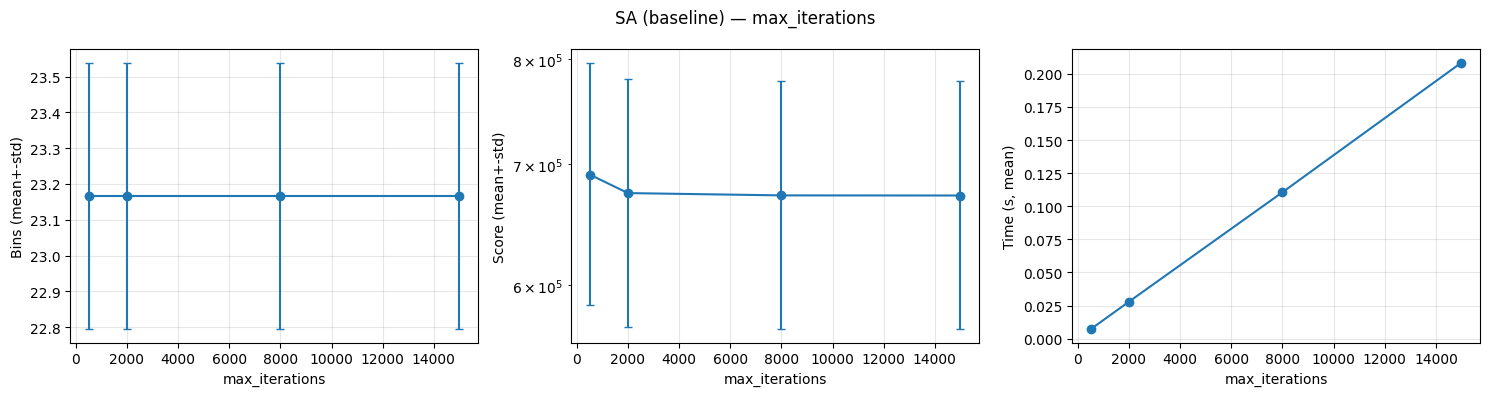

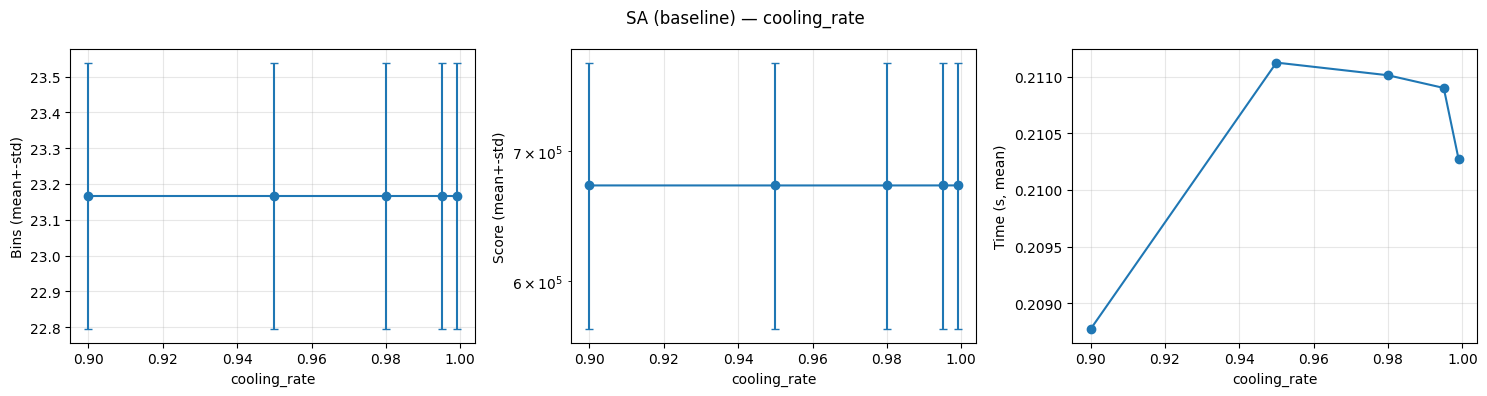

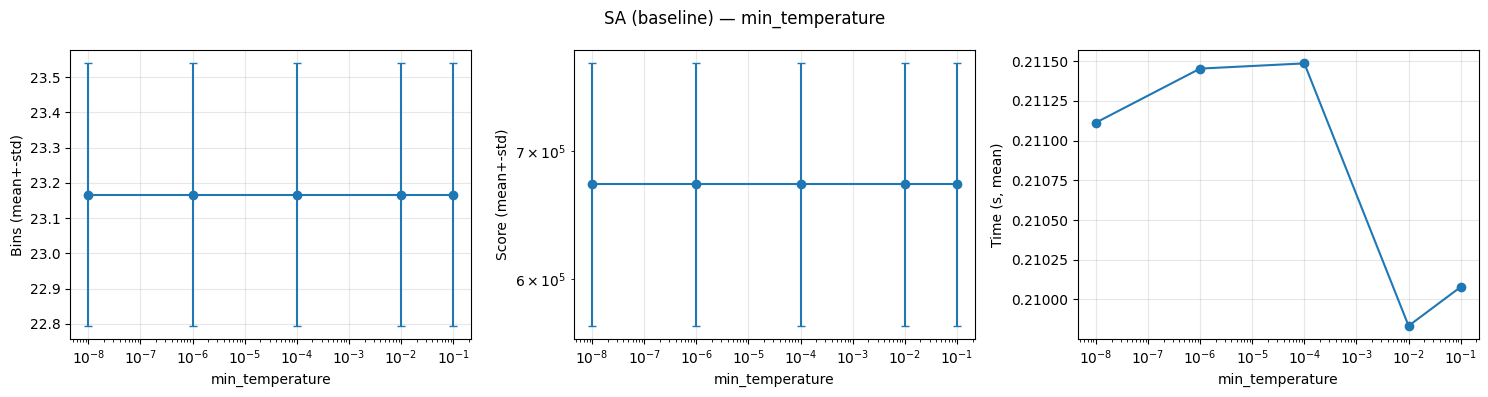


SA sensitivity — adaptive


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,adaptive,max_iterations,5.000000e+02,23.166667,0.372678,690476.777778,105955.634829,0.007307
1,adaptive,max_iterations,2.000000e+03,23.166667,0.372678,674397.000000,105837.842103,0.029577
2,adaptive,max_iterations,8.000000e+03,23.166667,0.372678,672431.000000,105409.085053,0.117931
3,adaptive,max_iterations,1.500000e+04,23.166667,0.372678,672339.555556,105403.620732,0.218812
4,adaptive,cooling_rate,9.000000e-01,23.166667,0.372678,672354.222222,105420.957360,0.218999
5,adaptive,cooling_rate,9.500000e-01,23.166667,0.372678,672339.555556,105403.620732,0.217914
6,adaptive,cooling_rate,9.800000e-01,23.166667,0.372678,672346.000000,105401.047195,0.219490
7,adaptive,cooling_rate,9.950000e-01,23.166667,0.372678,672347.000000,105409.543273,0.220135
8,adaptive,cooling_rate,9.990000e-01,23.166667,0.372678,681111.888889,109662.698569,0.219650
9,adaptive,min_temperature,1.000000e-08,23.166667,0.372678,672339.555556,105403.620732,0.217232


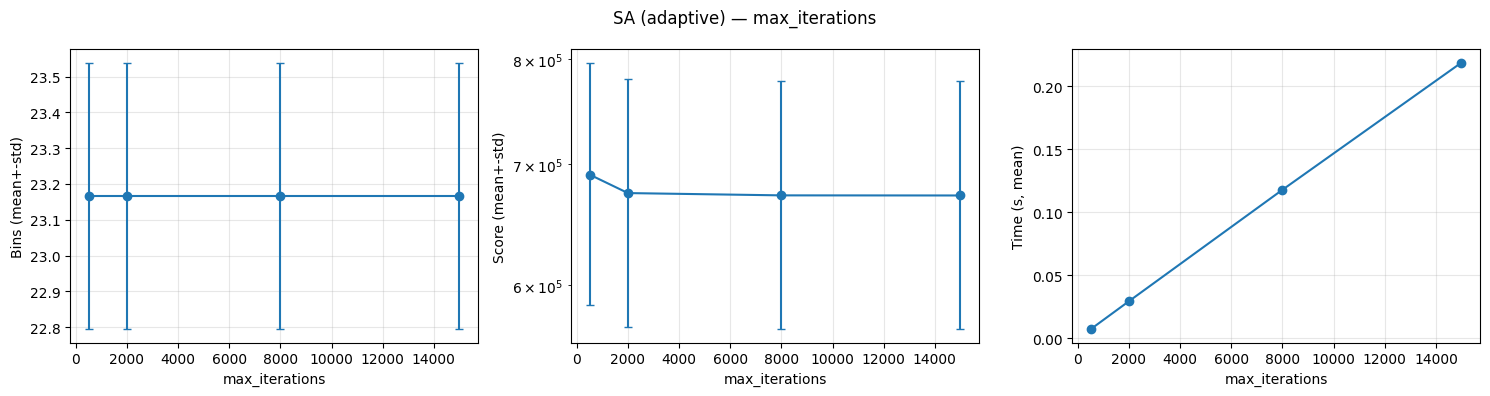

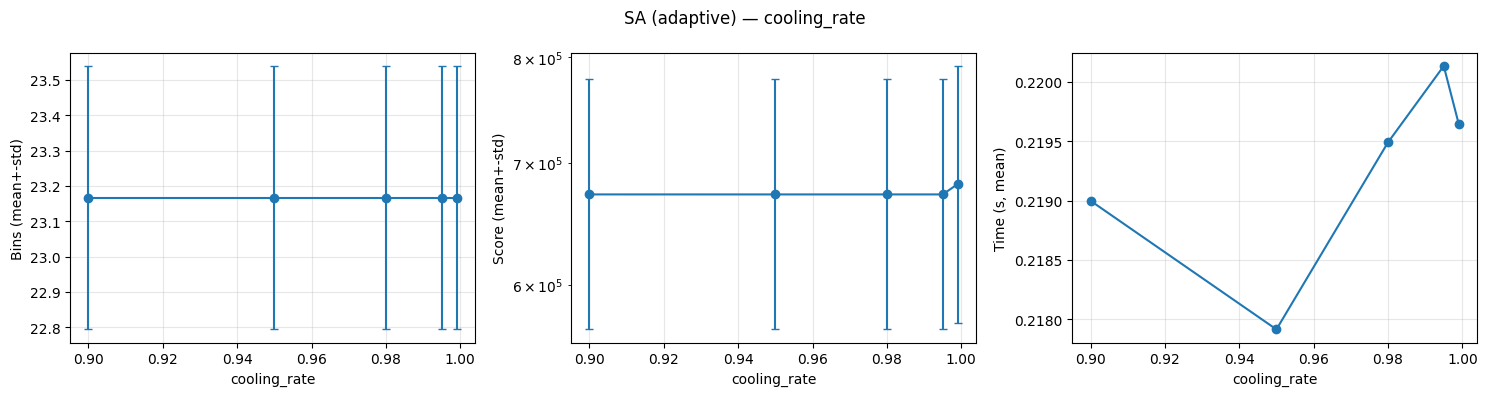

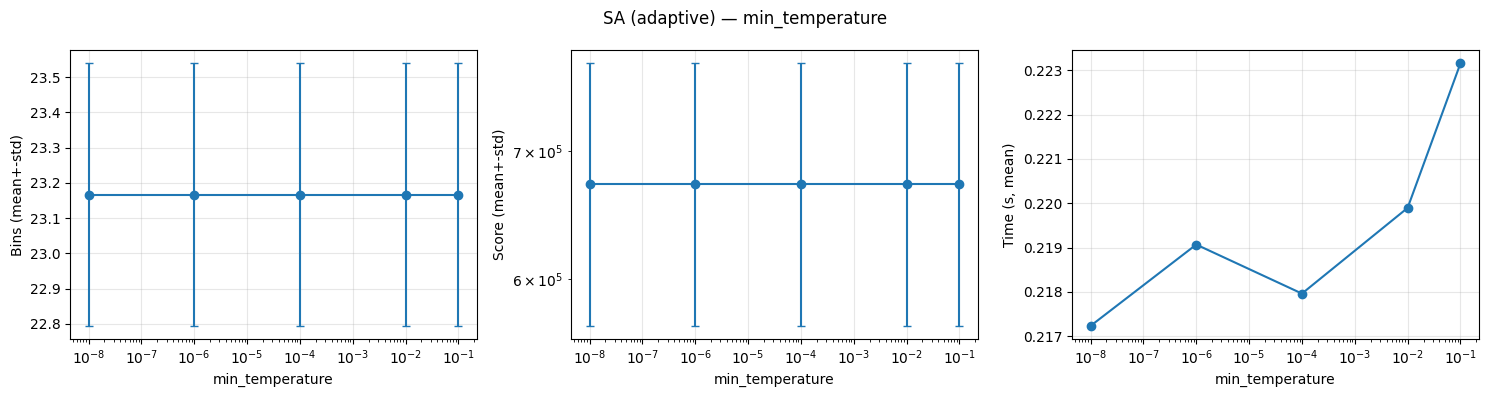

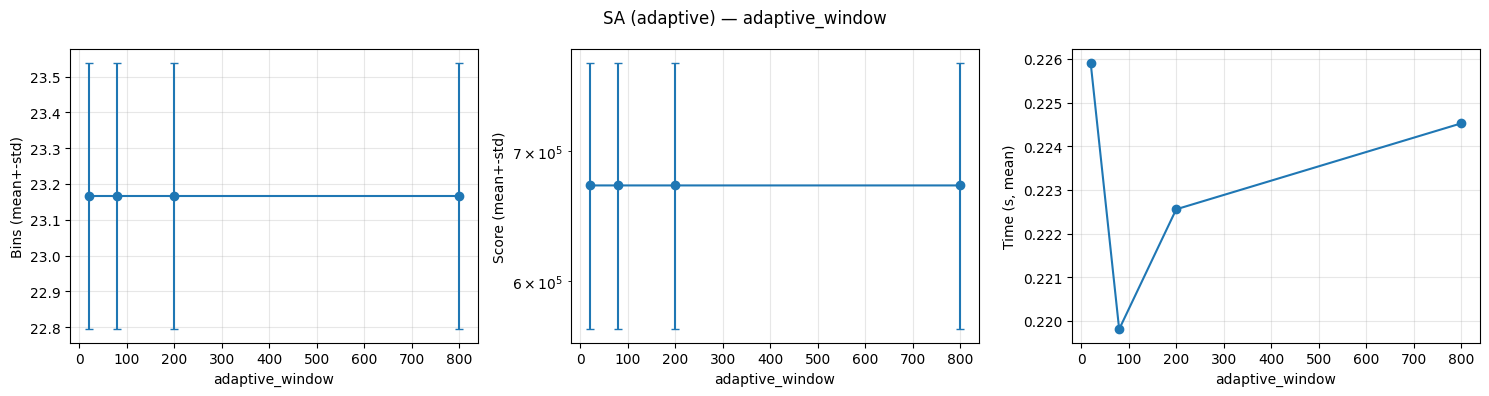

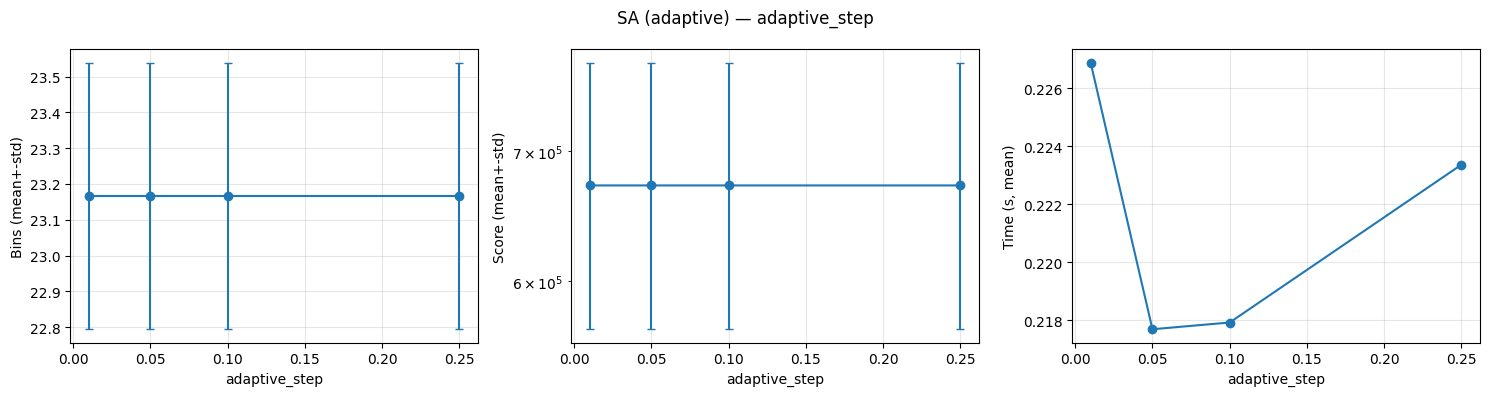

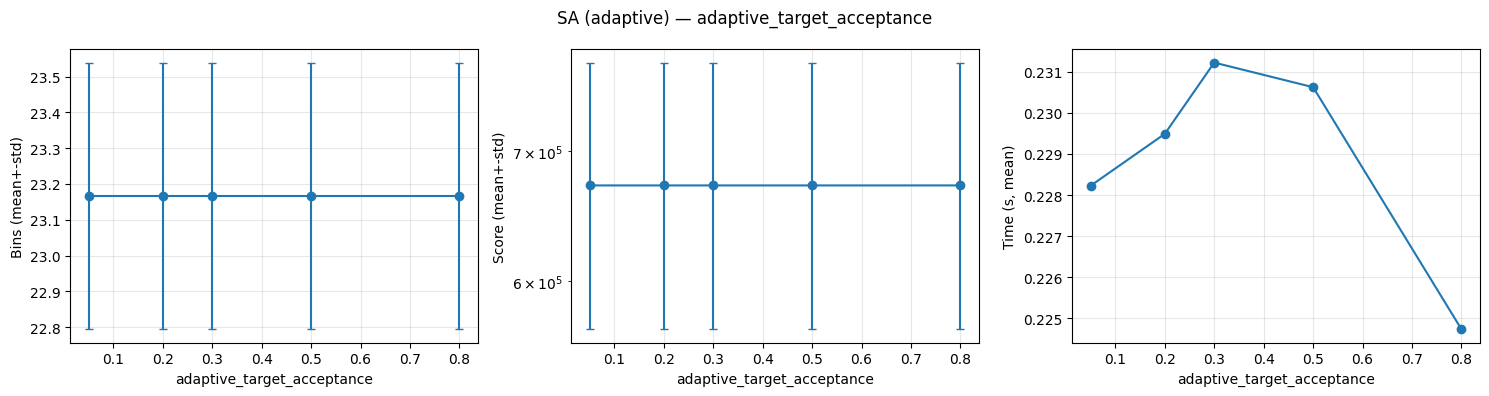


SA sensitivity — reheating


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,reheating,max_iterations,5.000000e+02,23.166667,0.372678,691580.888889,106617.534887,0.008016
1,reheating,max_iterations,2.000000e+03,23.166667,0.372678,674336.000000,105255.131612,0.030562
2,reheating,max_iterations,8.000000e+03,23.166667,0.372678,672447.111111,105404.946110,0.121385
3,reheating,max_iterations,1.500000e+04,23.166667,0.372678,672369.444444,105423.717555,0.230822
4,reheating,cooling_rate,9.000000e-01,23.166667,0.372678,672447.111111,105404.946110,0.120380
5,reheating,cooling_rate,9.500000e-01,23.166667,0.372678,672438.777778,105410.082950,0.119609
6,reheating,cooling_rate,9.800000e-01,23.166667,0.372678,672433.333333,105424.006505,0.119919
7,reheating,cooling_rate,9.950000e-01,23.166667,0.372678,672440.555556,105377.847014,0.120923
8,reheating,cooling_rate,9.990000e-01,23.166667,0.372678,672722.111111,105292.535670,0.121938
9,reheating,min_temperature,1.000000e-08,23.166667,0.372678,672447.111111,105404.946110,0.118598


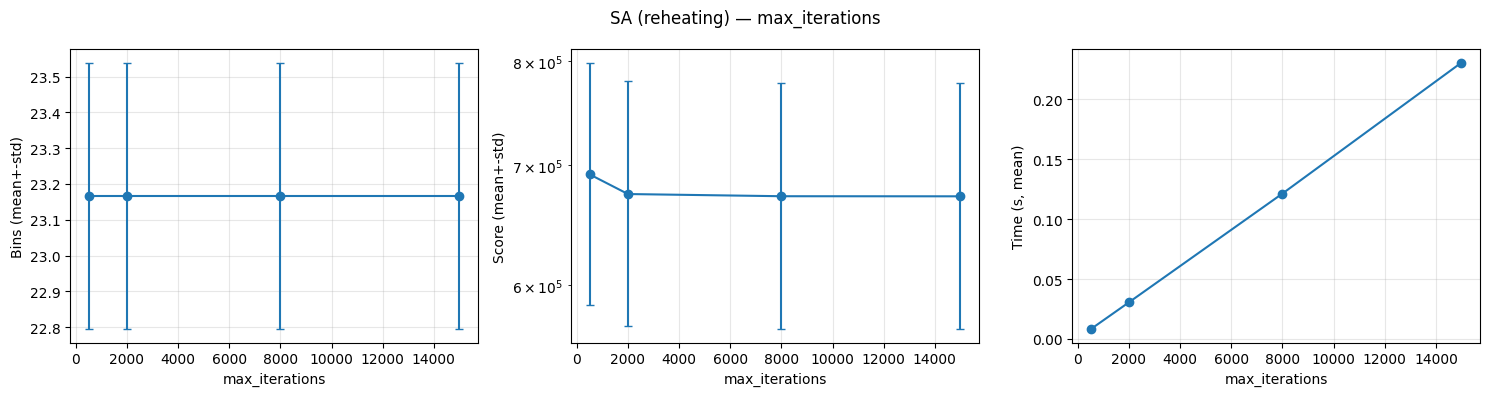

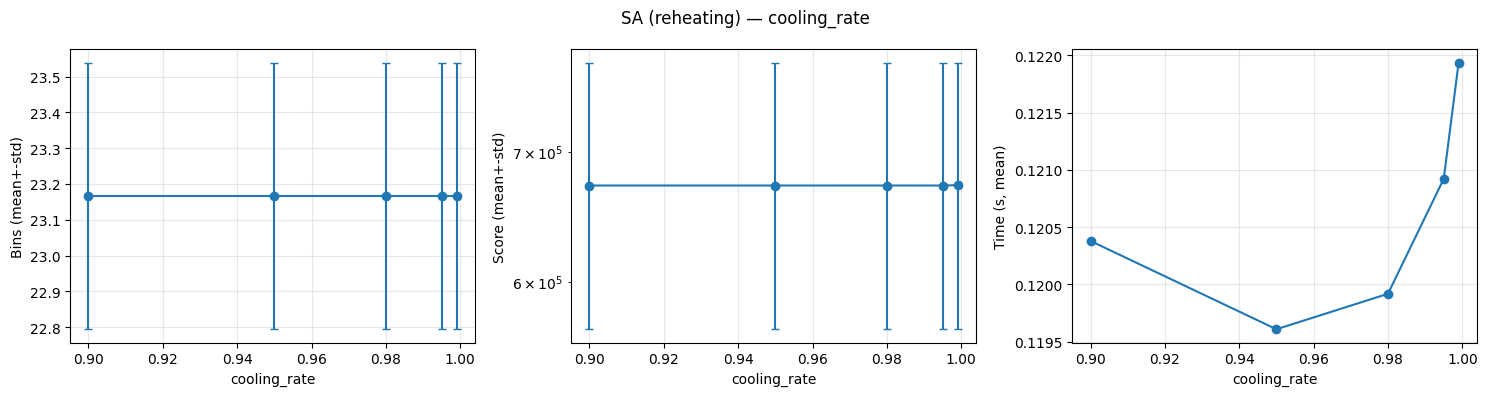

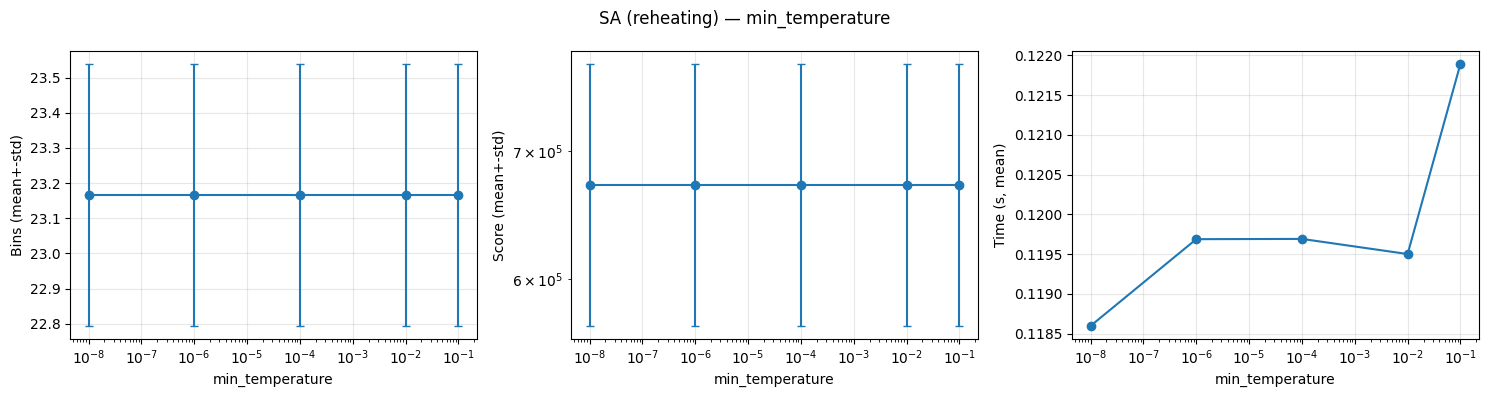

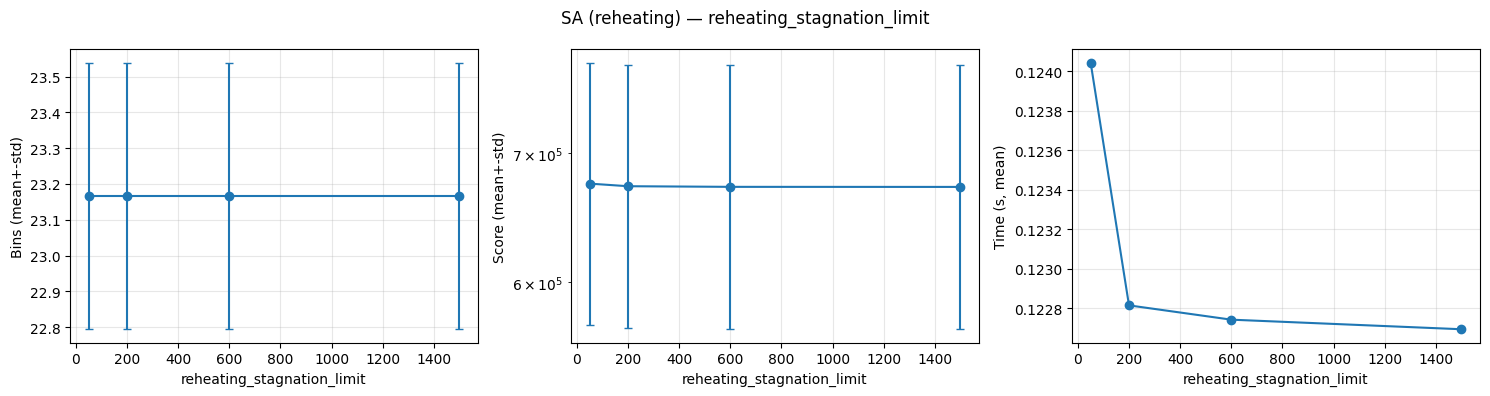

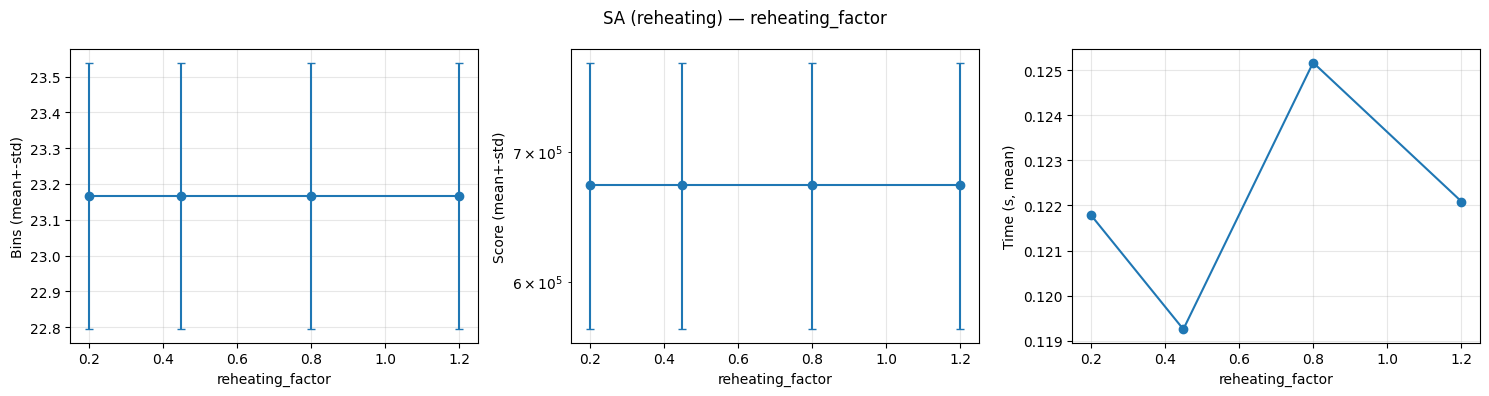

In [ ]:
# ── Sensibilité (variation 1 paramètre, autres fixés) ───────────────────────
SA_VARIANTS_TO_PLOT = ["baseline", "adaptive", "reheating"]


def sa_sensitivity_for(variant_name: str) -> pd.DataFrame:
    grid = SA_VARIANTS[variant_name]["grid"]
    base_params = best_sa_params_by_variant[variant_name]

    rows: list[dict] = []
    for param, values in grid.items():
        for v in values:
            params = dict(base_params)
            params[param] = v
            config = make_sa_config(params)

            df_runs = evaluate(
                method="SA",
                instances=tuning_instances,
                seeds=SEEDS,
                run_one=lambda inst, seed: run_sa(inst, seed, config),
            )
            rows.append(
                {
                    "variant": variant_name,
                    "param": param,
                    "value": v,
                    **summarize_runs(df_runs),
                }
            )
    return pd.DataFrame(rows)


for variant_name in SA_VARIANTS_TO_PLOT:
    print("\n" + "=" * 60)
    print("SA sensitivity —", variant_name)
    df = sa_sensitivity_for(variant_name)
    display(df)
    plot_sensitivity(df, title_prefix=f"SA ({variant_name}) — ")

---

## 5) Tuner — Tabu Search (TS) et variantes

On reproduit la même logique que pour SA:
- une section de tuning **par variante**
- une grille de paramètres par variante
- une comparaison finale entre variantes
- puis des graphes de sensibilité (variation un par un)

Variantes présentes dans `solver.py` :
- `ts` (Tabu Search)
- `rts` (Reactive Tabu Search)
- `lnts` (Tabu Search + LNS)
- `hybrid` (Reactive + LNS + Diversification)

On tune les paramètres communs (`tabu_tenure`, `max_candidates`, `max_iterations`, `patience_ratio`)
et les paramètres spécifiques de chaque variante (tenure réactive, déclencheurs LNS, diversification).


In [ ]:
TS_ROUNDS = 1

TS_COMMON_GRID = {
    "tabu_tenure": [2, 4, 6, 10, 16],
    "max_candidates": [12, 24, 40, 64, 96],
    "max_iterations": [800, 2_500, 6_000, 10_000, 12_000],
    "patience_ratio": [0.08, 0.15, 0.30, 0.55],
}

TS_REACTIVE_GRID = {
    "base_tenure_scale": [0.5, 0.8, 1.1, 1.5],
    "min_tenure": [1, 2, 3, 5],
    "max_tenure_scale": [2.0, 3.0, 4.0, 6.0],
    "cycle_window": [120, 250, 400],
    "cycle_check_period": [20, 40, 80],
    "stagnation_boost_trigger": [120, 220, 300, 420],
}

TS_LNS_GRID = {
    "lns_period": [180, 320, 450, 700],
    "lns_stagnation_trigger": [120, 200, 260, 360],
    "lns_refine_iterations": [8, 14, 24, 36],
    "lns_refine_candidates": [6, 10, 16, 24],
}

TS_DIVERSIFICATION_GRID = {
    "long_stagnation_trigger": [220, 350, 500, 700],
    "diversification_growth": [0.01, 0.03, 0.06, 0.10],
    "diversification_max_weight": [8.0, 14.0, 20.0, 30.0],
}

TS_DEFAULTS = {
    "tabu_tenure": 6,
    "max_candidates": 32,
    "max_iterations": 2_500,
    "patience_ratio": 0.30,
    "diversification_weight": 0.0,
    "base_tenure_scale": 0.8,
    "min_tenure": 2,
    "max_tenure_scale": 4.0,
    "cycle_window": 250,
    "cycle_check_period": 40,
    "stagnation_boost_trigger": 300,
    "lns_period": 450,
    "lns_stagnation_trigger": 260,
    "long_stagnation_trigger": 500,
    "lns_refine_iterations": 14,
    "lns_refine_candidates": 10,
    "diversification_max_weight": 20.0,
    "diversification_growth": 0.03,
}

TS_VARIANTS = {
    "baseline": {
        "variant": "ts",
        "grid": {**TS_COMMON_GRID, "diversification_weight": [0.0, 0.2, 0.8, 2.5]},
    },
    "reactive": {
        "variant": "rts",
        "grid": {**TS_COMMON_GRID, **TS_REACTIVE_GRID},
    },
    "lns": {
        "variant": "lnts",
        "grid": {**TS_COMMON_GRID, **TS_REACTIVE_GRID, **TS_LNS_GRID},
    },
    "hybrid": {
        "variant": "hybrid",
        "grid": {
            **TS_COMMON_GRID,
            **TS_REACTIVE_GRID,
            **TS_LNS_GRID,
            **TS_DIVERSIFICATION_GRID,
        },
    },
}


def eval_ts_variant_params(variant_name: str, params: dict[str, object]) -> dict:
    variant_code = TS_VARIANTS[variant_name]["variant"]

    df_runs = evaluate(
        method=f"TS/{variant_name}",
        instances=tuning_instances,
        seeds=SEEDS,
        run_one=lambda inst, seed: run_tabu_variant_custom(
            inst,
            seed,
            variant=variant_code,
            tabu_tenure=int(params["tabu_tenure"]),
            max_iterations=int(params["max_iterations"]),
            max_candidates=int(params["max_candidates"]),
            patience_ratio=float(params["patience_ratio"]),
            diversification_weight=float(params.get("diversification_weight", 0.0)),
            base_tenure_scale=float(
                params.get("base_tenure_scale", TS_DEFAULTS["base_tenure_scale"])
            ),
            min_tenure=int(params.get("min_tenure", TS_DEFAULTS["min_tenure"])),
            max_tenure_scale=float(
                params.get("max_tenure_scale", TS_DEFAULTS["max_tenure_scale"])
            ),
            cycle_window=int(params.get("cycle_window", TS_DEFAULTS["cycle_window"])),
            cycle_check_period=int(
                params.get("cycle_check_period", TS_DEFAULTS["cycle_check_period"])
            ),
            stagnation_boost_trigger=int(
                params.get(
                    "stagnation_boost_trigger", TS_DEFAULTS["stagnation_boost_trigger"]
                )
            ),
            lns_period=int(params.get("lns_period", TS_DEFAULTS["lns_period"])),
            lns_stagnation_trigger=int(
                params.get(
                    "lns_stagnation_trigger", TS_DEFAULTS["lns_stagnation_trigger"]
                )
            ),
            long_stagnation_trigger=int(
                params.get(
                    "long_stagnation_trigger", TS_DEFAULTS["long_stagnation_trigger"]
                )
            ),
            lns_refine_iterations=int(
                params.get(
                    "lns_refine_iterations", TS_DEFAULTS["lns_refine_iterations"]
                )
            ),
            lns_refine_candidates=int(
                params.get(
                    "lns_refine_candidates", TS_DEFAULTS["lns_refine_candidates"]
                )
            ),
            diversification_max_weight=float(
                params.get(
                    "diversification_max_weight",
                    TS_DEFAULTS["diversification_max_weight"],
                )
            ),
            diversification_growth=float(
                params.get(
                    "diversification_growth", TS_DEFAULTS["diversification_growth"]
                )
            ),
        ),
    )
    return summarize_runs(df_runs)


best_ts_params_by_variant: dict[str, dict[str, object]] = {}
ts_tuning_log_by_variant: dict[str, pd.DataFrame] = {}

ts_compare_rows: list[dict] = []
for variant_name, spec in TS_VARIANTS.items():
    grid = spec["grid"]
    base = dict(TS_DEFAULTS)

    print("\n" + "=" * 60)
    print(f"TS variant: {variant_name}")
    best_params, log = tune_one_by_one(
        label=f"TS/{variant_name}",
        base_params=base,
        grid=grid,
        eval_params=lambda params, v=variant_name: eval_ts_variant_params(v, params),
        rounds=TS_ROUNDS,
    )
    summary = eval_ts_variant_params(variant_name, best_params)

    best_ts_params_by_variant[variant_name] = best_params
    ts_tuning_log_by_variant[variant_name] = log

    ts_compare_rows.append(
        {
            "variant": variant_name,
            "solver_variant": spec["variant"],
            **summary,
        }
    )

ts_compare = pd.DataFrame(ts_compare_rows).sort_values(SORT_COLS, ignore_index=True)
best_ts_variant = ts_compare.loc[0, "variant"]
best_ts_params = best_ts_params_by_variant[best_ts_variant]

print("\nBest overall TS variant:", best_ts_variant)
display(ts_compare)
print("Best TS params:")
display(best_ts_params)


TS variant: baseline
[TS/baseline] Round 1/1 — start: {'tabu_tenure': 6, 'max_candidates': 32, 'max_iterations': 2500, 'patience_ratio': 0.3, 'diversification_weight': 0.0, 'base_tenure_scale': 0.8, 'min_tenure': 2, 'max_tenure_scale': 4.0, 'cycle_window': 250, 'cycle_check_period': 40, 'stagnation_boost_trigger': 300, 'lns_period': 450, 'lns_stagnation_trigger': 260, 'long_stagnation_trigger': 500, 'lns_refine_iterations': 14, 'lns_refine_candidates': 10, 'diversification_max_weight': 20.0, 'diversification_growth': 0.03}
  - best tabu_tenure=16 | bins_mean=23.167 | score_mean=672349.3 | time_mean=0.529s
  - best max_candidates=64 | bins_mean=23.167 | score_mean=672333.9 | time_mean=0.872s
  - best max_iterations=2500 | bins_mean=23.167 | score_mean=672333.9 | time_mean=0.852s
  - best patience_ratio=0.3 | bins_mean=23.167 | score_mean=672333.9 | time_mean=0.852s
  - best diversification_weight=0.0 | bins_mean=23.167 | score_mean=672333.9 | time_mean=0.856s

TS variant: reactive
[TS/

,variant,solver_variant,bins_mean,bins_std,score_mean,score_std,time_mean
0,lns,lnts,23.166667,0.372678,672333.666667,105407.120496,1.222836
1,hybrid,hybrid,23.166667,0.372678,672333.666667,105407.120496,1.241554
2,reactive,rts,23.166667,0.372678,672333.888889,105407.021679,0.898669
3,baseline,ts,23.166667,0.372678,672333.888889,105407.021679,0.906133


Best TS params:


{'tabu_tenure': np.int64(10),
 'max_candidates': np.int64(64),
 'max_iterations': np.int64(2500),
 'patience_ratio': np.float64(0.3),
 'diversification_weight': 0.0,
 'base_tenure_scale': np.float64(1.5),
 'min_tenure': np.int64(3),
 'max_tenure_scale': np.float64(6.0),
 'cycle_window': np.int64(250),
 'cycle_check_period': np.int64(40),
 'stagnation_boost_trigger': np.int64(120),
 'lns_period': np.int64(450),
 'lns_stagnation_trigger': np.int64(260),
 'long_stagnation_trigger': 500,
 'lns_refine_iterations': np.int64(8),
 'lns_refine_candidates': np.int64(6),
 'diversification_max_weight': 20.0,
 'diversification_growth': 0.03}


TS sensitivity — baseline


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,baseline,tabu_tenure,2.00,23.166667,0.372678,672333.888889,105407.021679,0.919505
1,baseline,tabu_tenure,4.00,23.166667,0.372678,672333.888889,105407.021679,0.930629
2,baseline,tabu_tenure,6.00,23.166667,0.372678,672333.888889,105407.021679,0.911042
3,baseline,tabu_tenure,10.00,23.166667,0.372678,672333.888889,105407.021679,0.901602
4,baseline,tabu_tenure,16.00,23.166667,0.372678,672333.888889,105407.021679,0.898810
5,baseline,max_candidates,12.00,23.166667,0.372678,672346.000000,105415.032120,0.320261
6,baseline,max_candidates,24.00,23.166667,0.372678,672343.666667,105401.157825,0.521993
7,baseline,max_candidates,40.00,23.166667,0.372678,672343.444444,105400.897246,0.669695
8,baseline,max_candidates,64.00,23.166667,0.372678,672333.888889,105407.021679,0.899727
9,baseline,max_candidates,96.00,23.166667,0.372678,672340.222222,105404.166574,1.133505


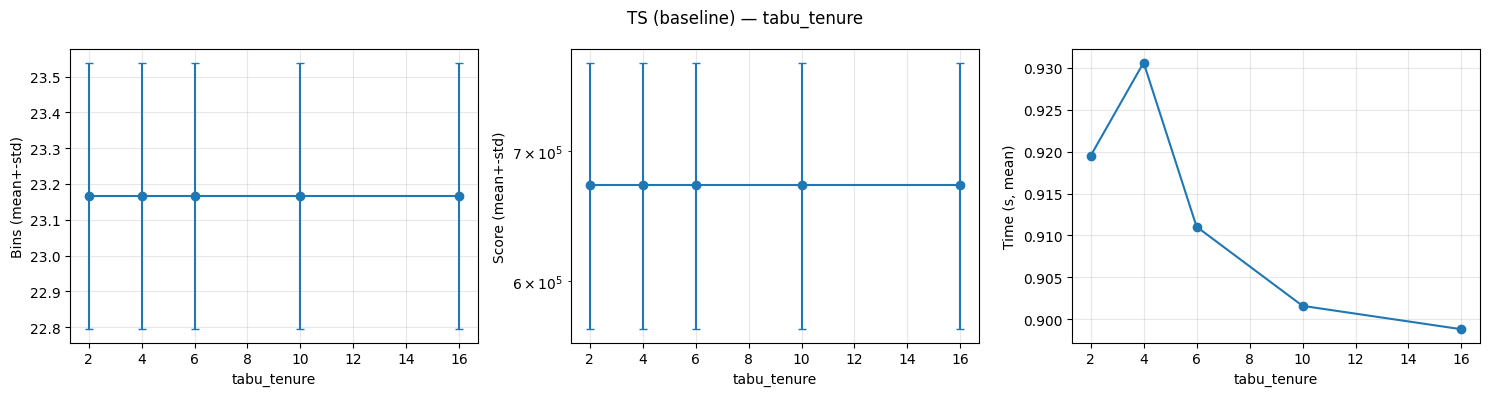

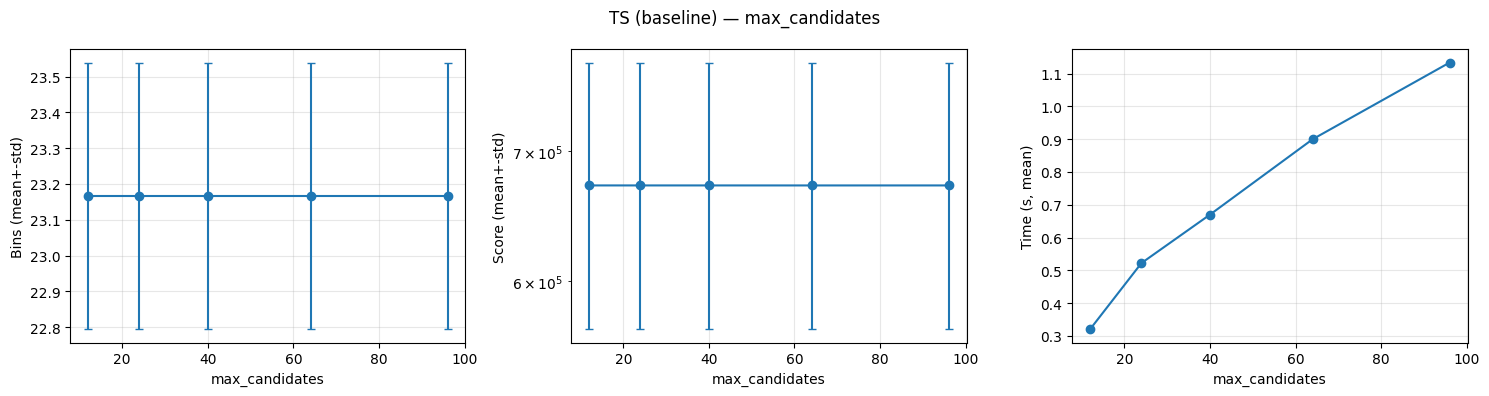

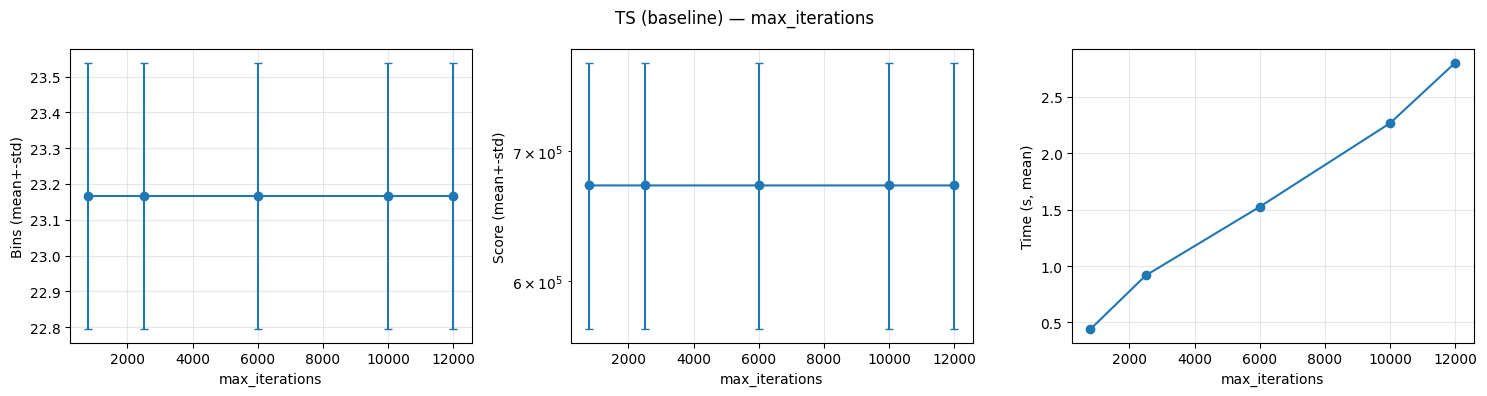

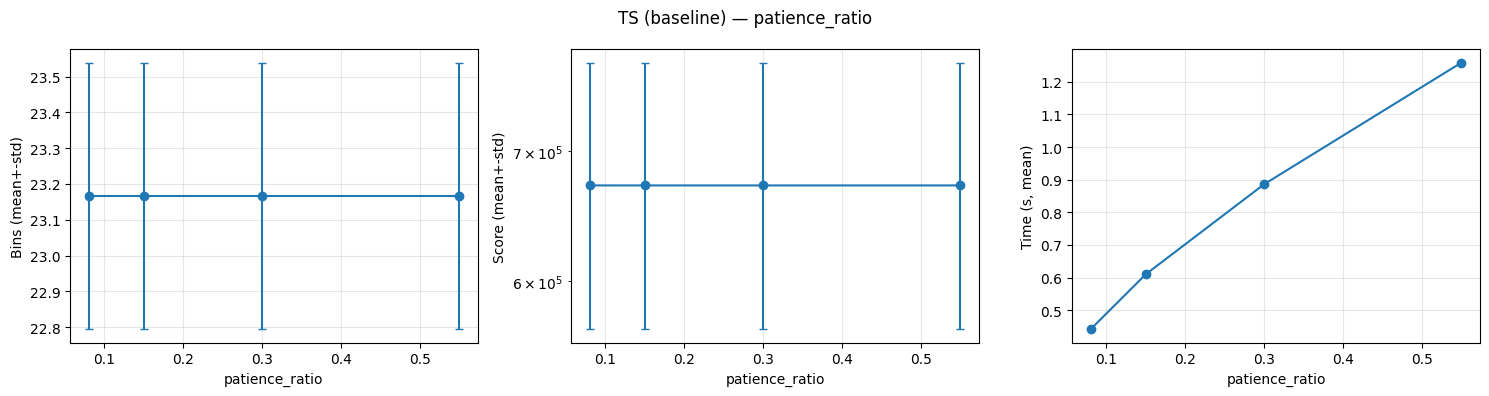

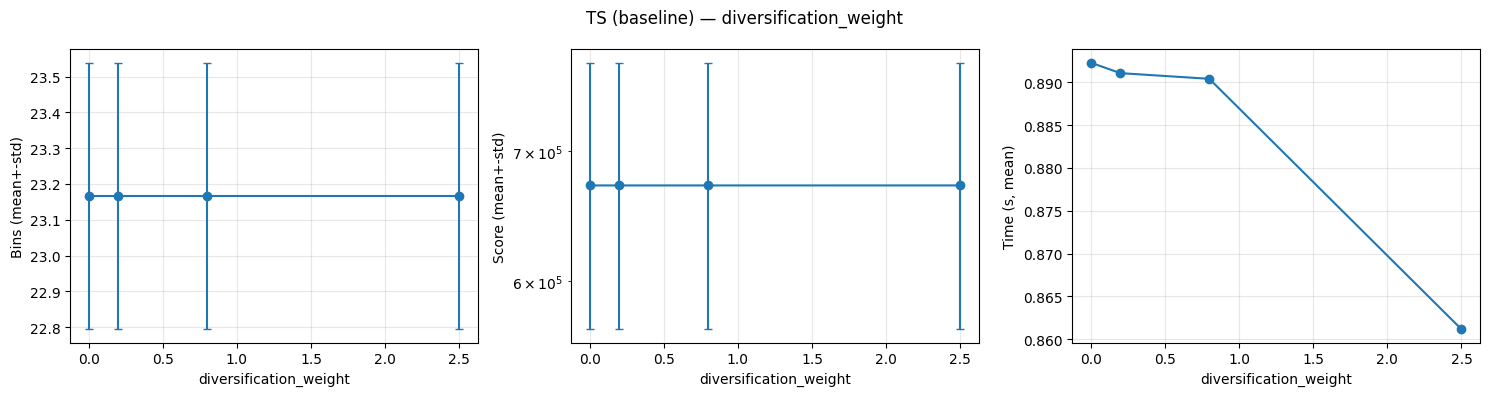


TS sensitivity — reactive


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,reactive,tabu_tenure,2.00,23.166667,0.372678,672333.888889,105407.021679,0.865678
1,reactive,tabu_tenure,4.00,23.166667,0.372678,672333.888889,105407.021679,0.866476
2,reactive,tabu_tenure,6.00,23.166667,0.372678,672333.888889,105407.021679,0.856758
3,reactive,tabu_tenure,10.00,23.166667,0.372678,672333.888889,105407.021679,0.864317
4,reactive,tabu_tenure,16.00,23.166667,0.372678,672333.888889,105407.021679,0.863189
5,reactive,max_candidates,12.00,23.166667,0.372678,672346.000000,105415.032120,0.307678
6,reactive,max_candidates,24.00,23.166667,0.372678,672343.666667,105401.157825,0.512325
7,reactive,max_candidates,40.00,23.166667,0.372678,672343.444444,105400.897246,0.663737
8,reactive,max_candidates,64.00,23.166667,0.372678,672333.888889,105407.021679,0.891872
9,reactive,max_candidates,96.00,23.166667,0.372678,672340.222222,105404.166574,1.103041


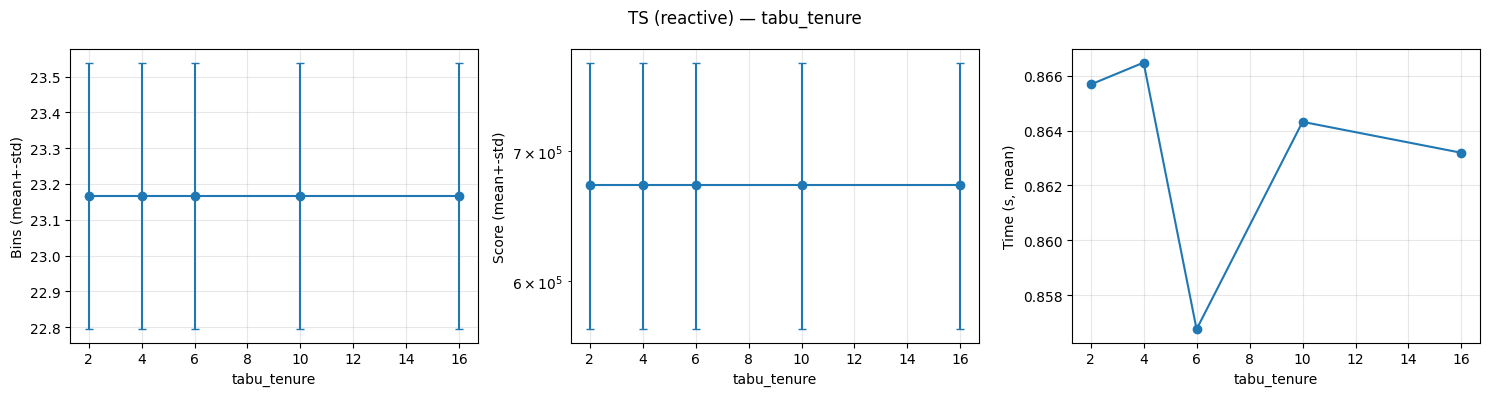

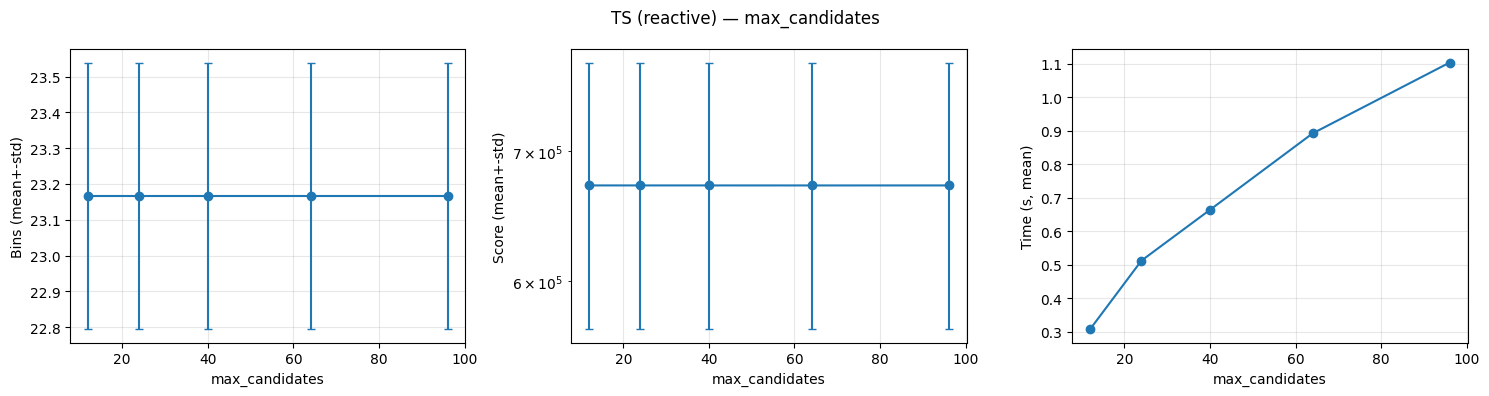

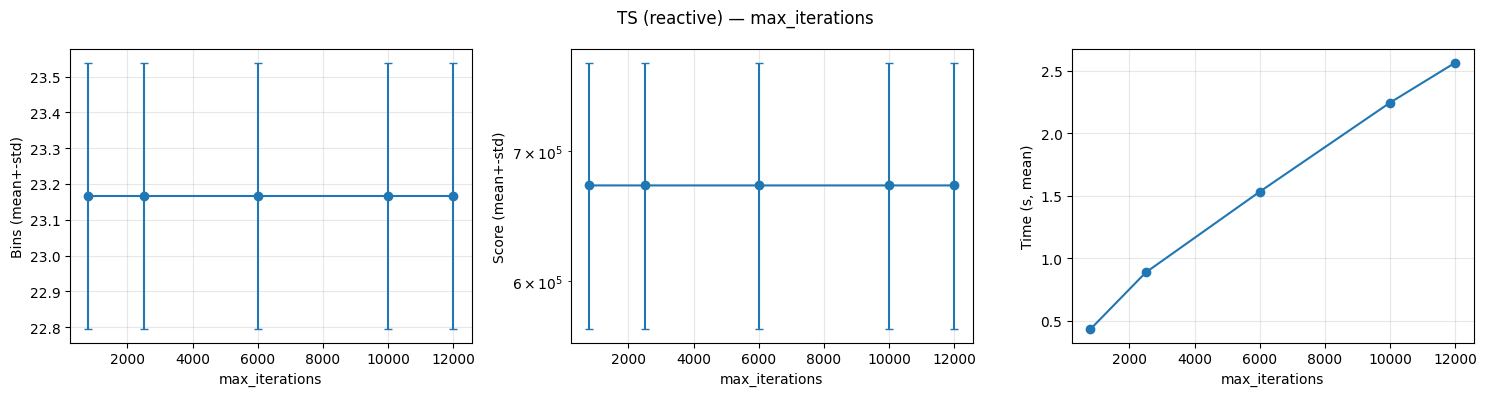

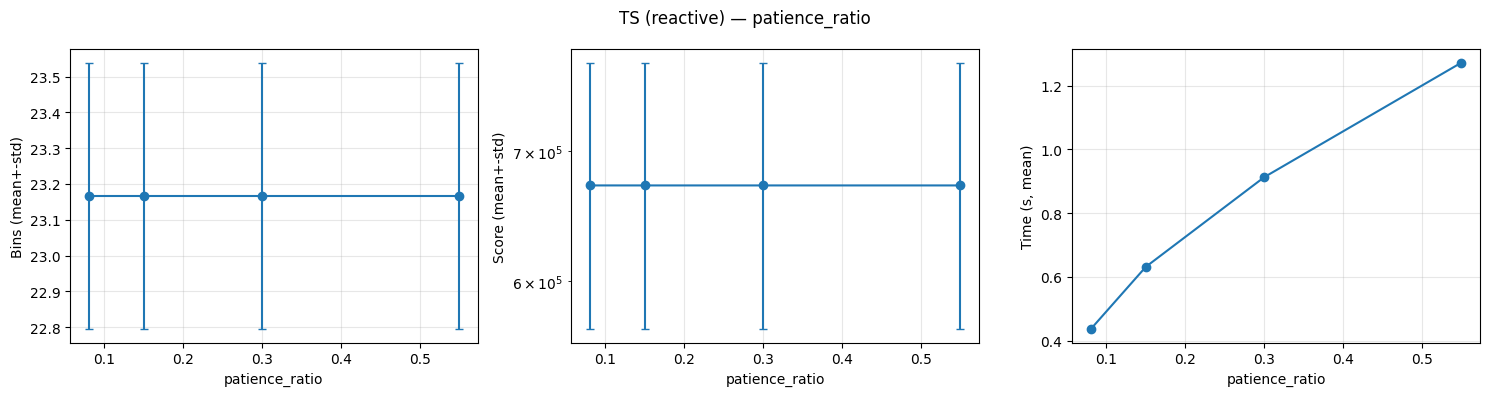

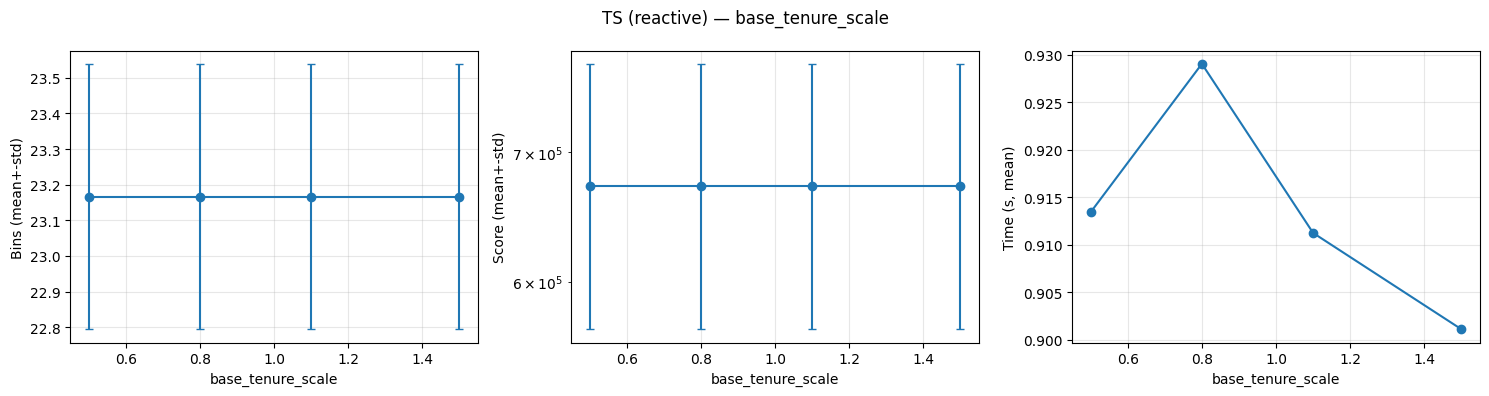

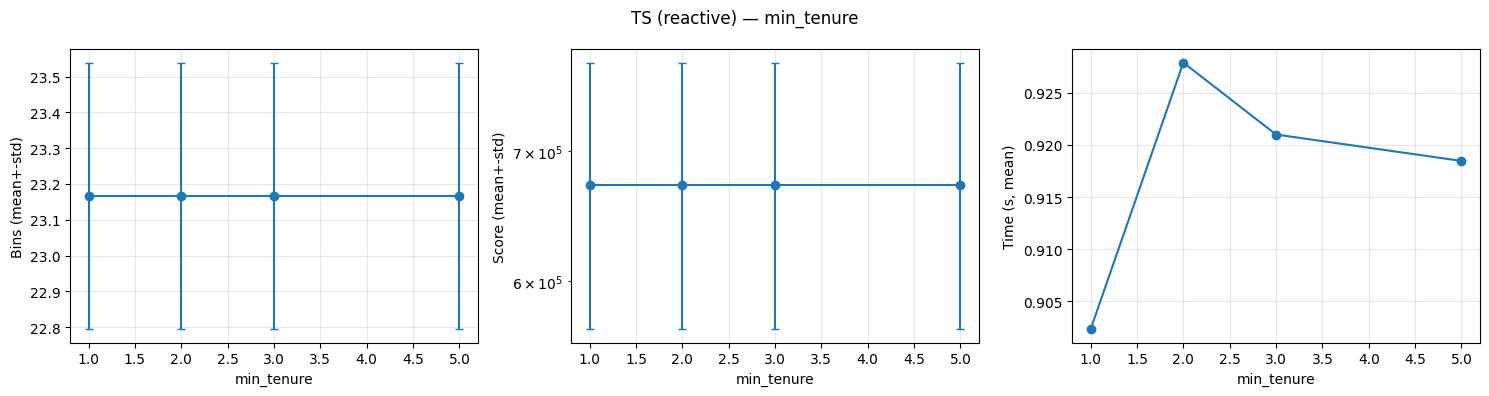

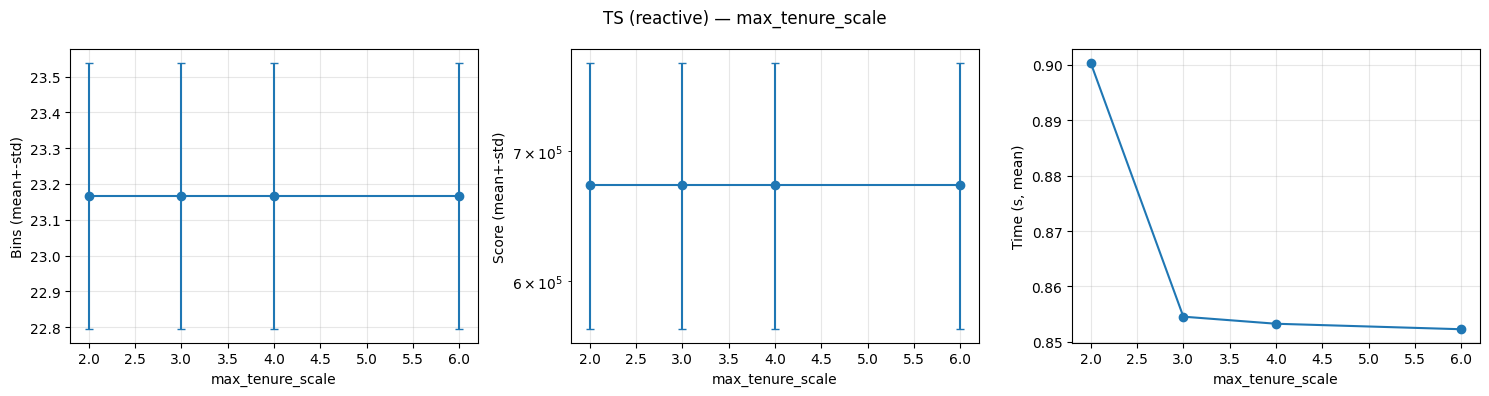

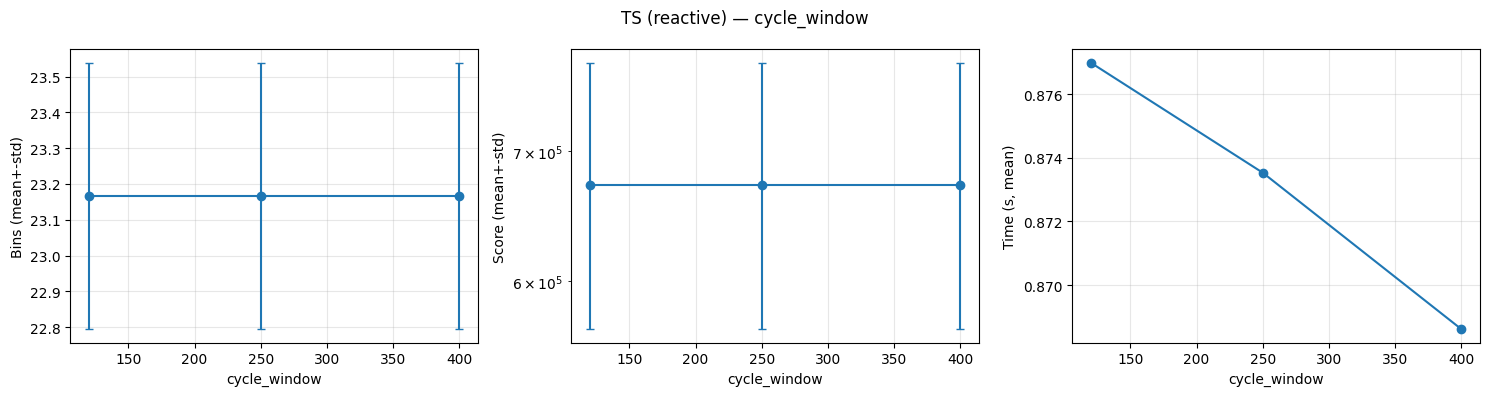

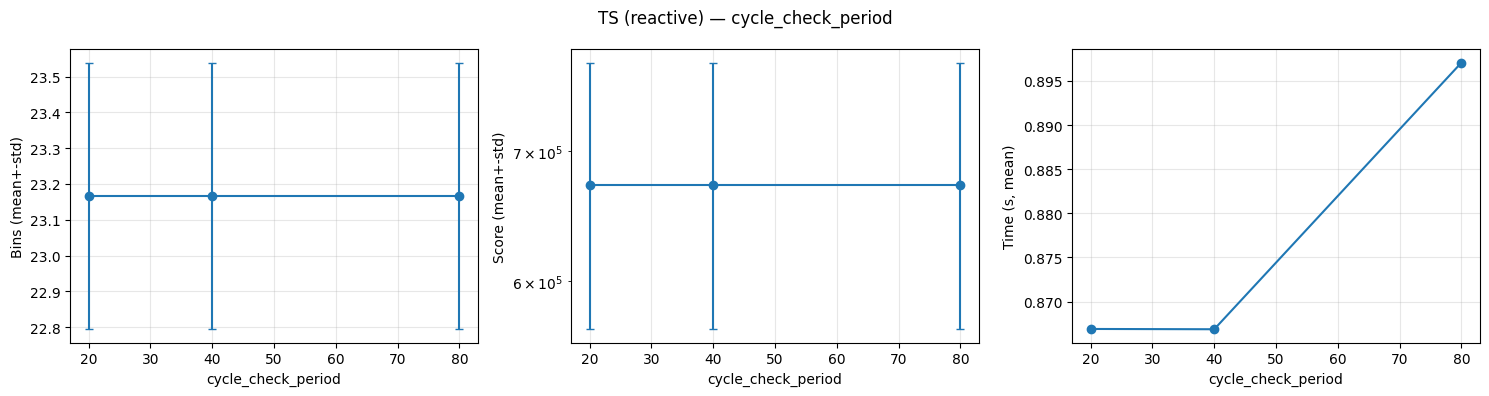

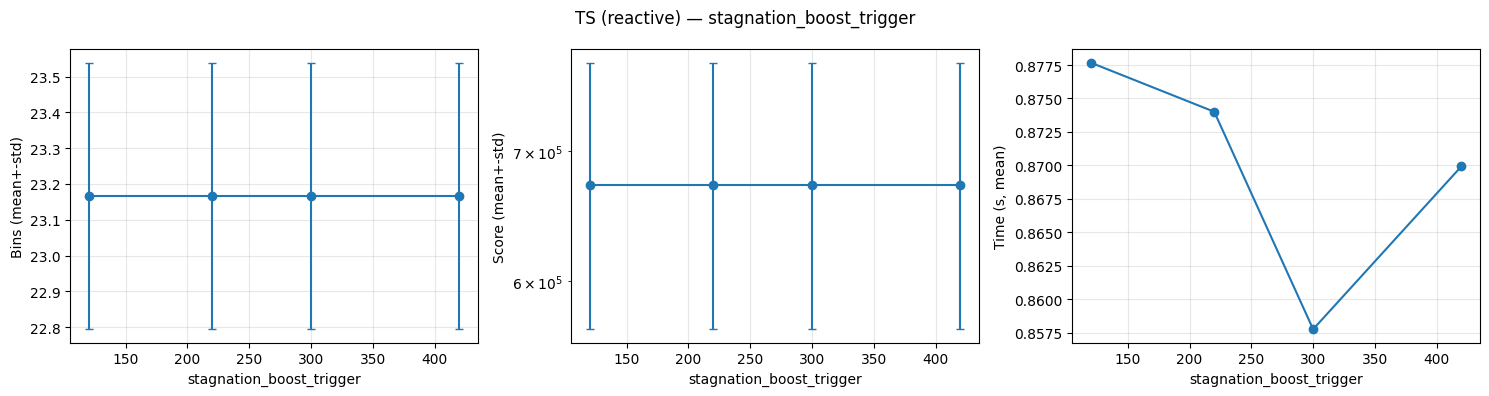


TS sensitivity — lns


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,lns,tabu_tenure,2.00,23.166667,0.372678,672333.666667,105407.120496,1.203445
1,lns,tabu_tenure,4.00,23.166667,0.372678,672333.666667,105407.120496,1.214636
2,lns,tabu_tenure,6.00,23.166667,0.372678,672333.666667,105407.120496,1.199559
3,lns,tabu_tenure,10.00,23.166667,0.372678,672333.666667,105407.120496,1.192412
4,lns,tabu_tenure,16.00,23.166667,0.372678,672333.666667,105407.120496,1.179258
5,lns,max_candidates,12.00,23.166667,0.372678,672344.555556,105405.275413,0.491147
6,lns,max_candidates,24.00,23.166667,0.372678,672343.444444,105401.227762,0.870300
7,lns,max_candidates,40.00,23.166667,0.372678,672344.777778,105400.269578,0.947011
8,lns,max_candidates,64.00,23.166667,0.372678,672333.666667,105407.120496,1.176003
9,lns,max_candidates,96.00,23.166667,0.372678,672340.222222,105404.166574,1.383012


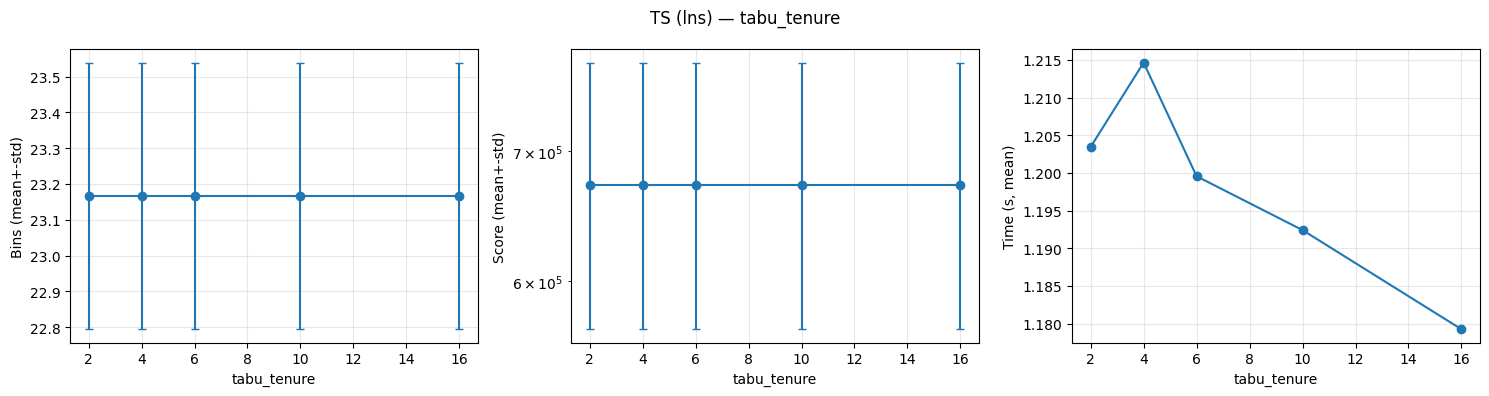

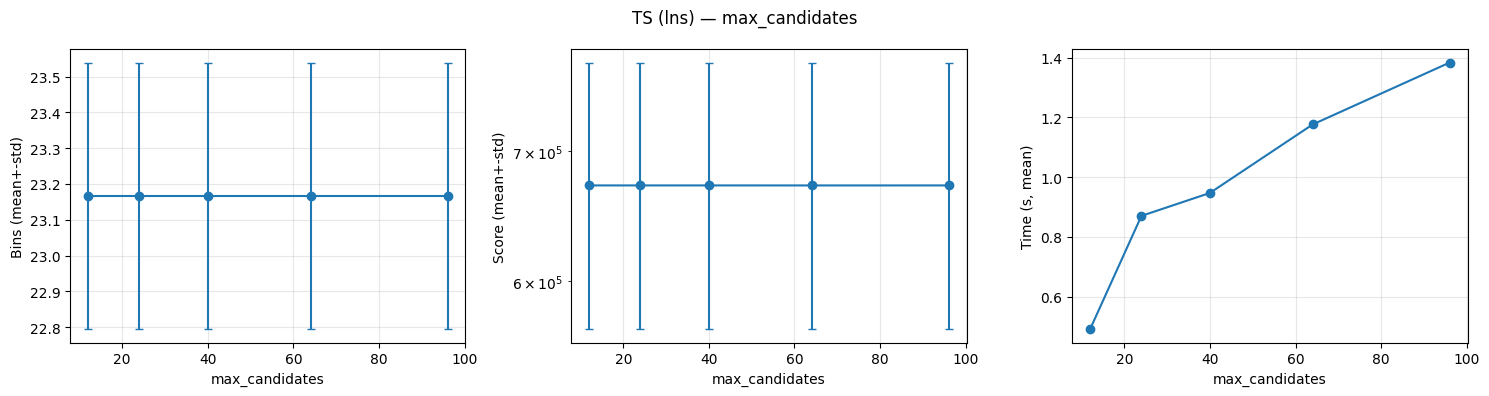

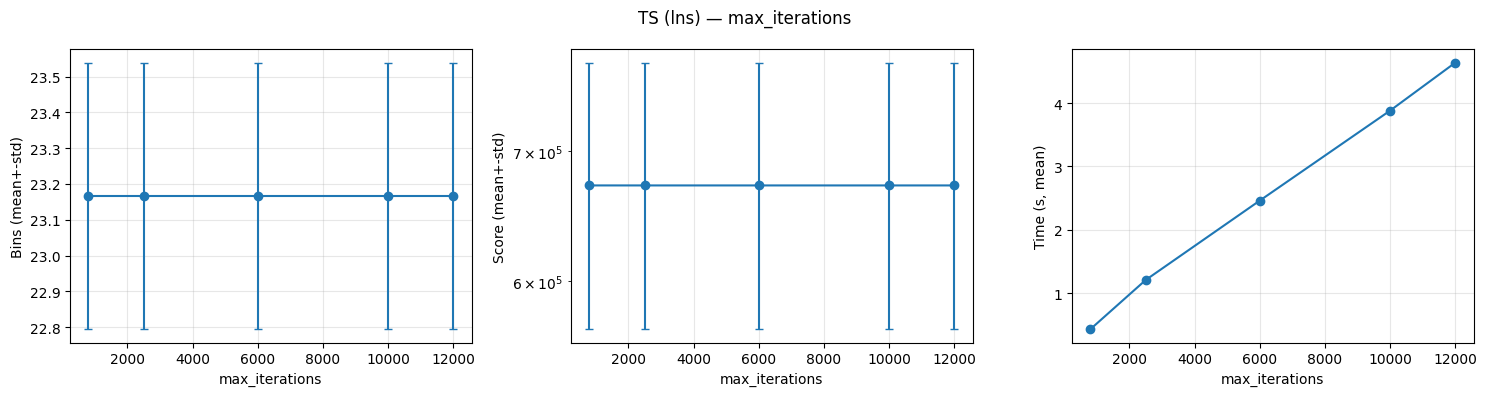

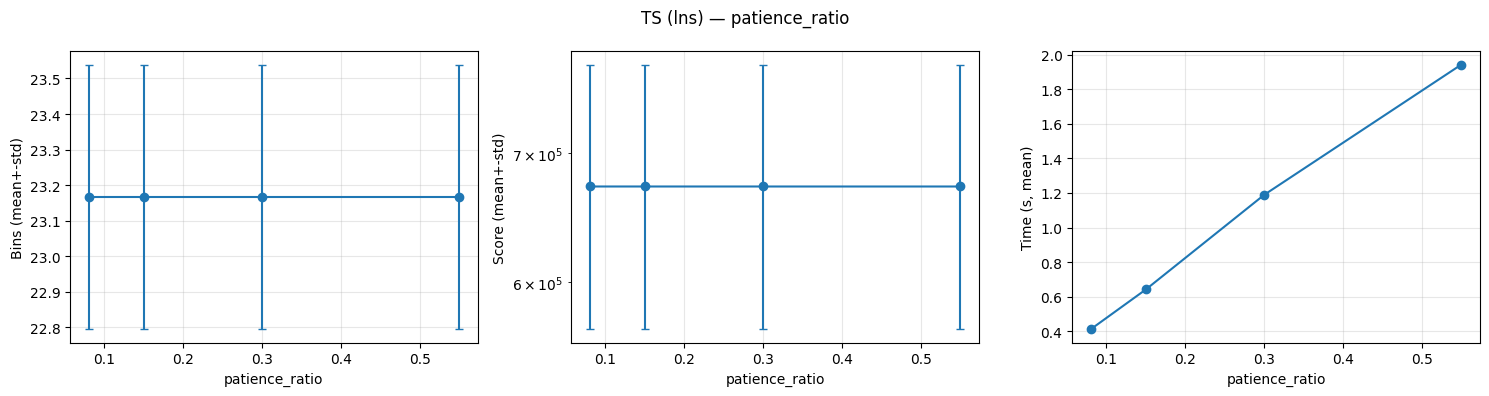

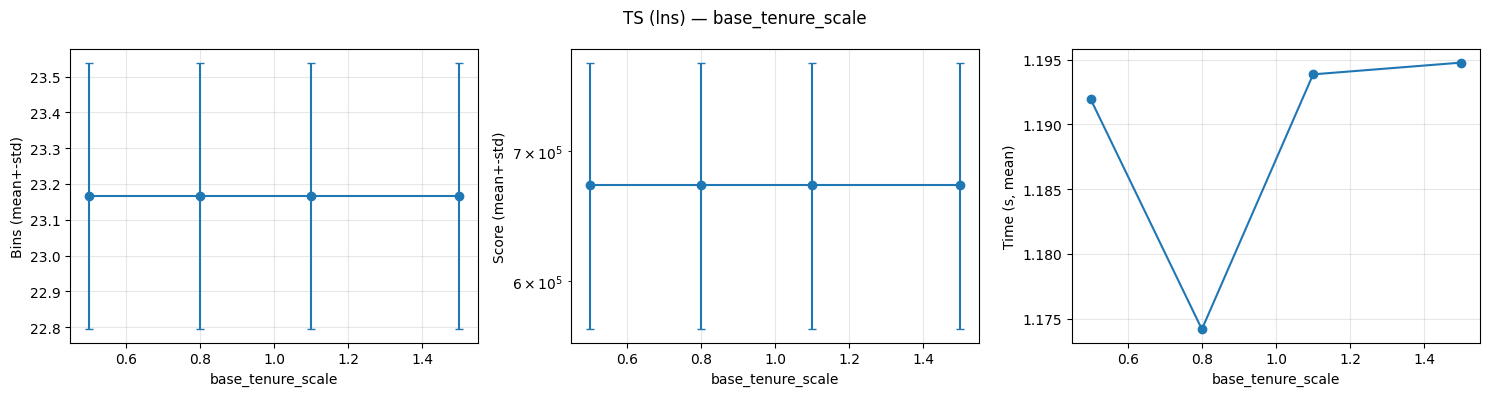

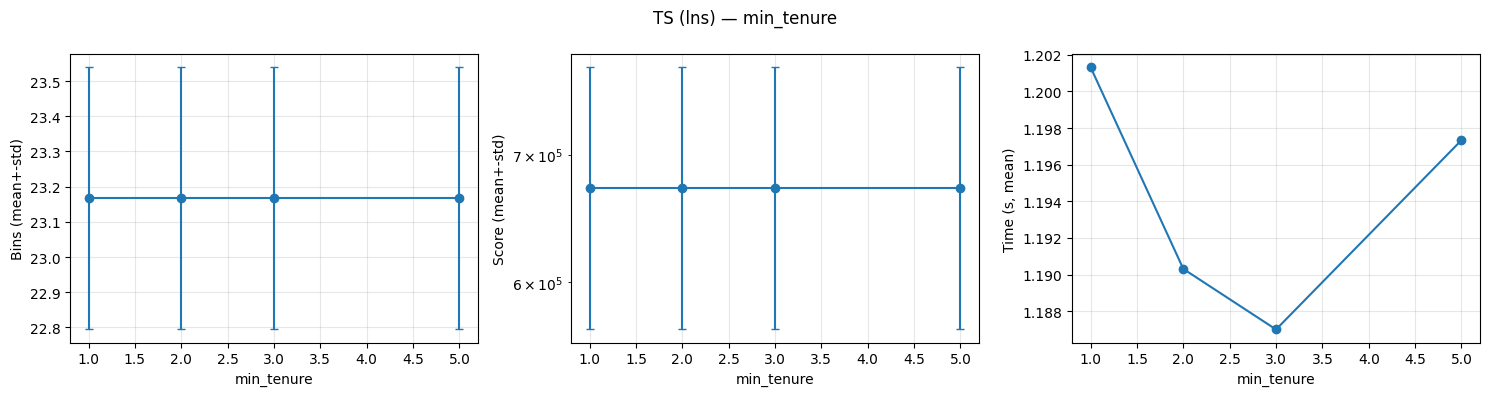

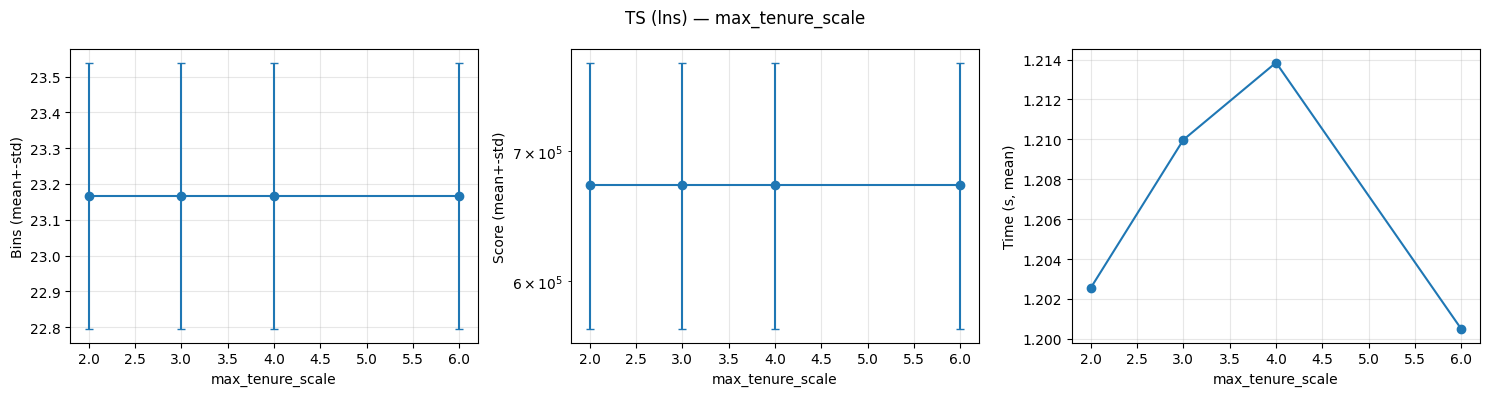

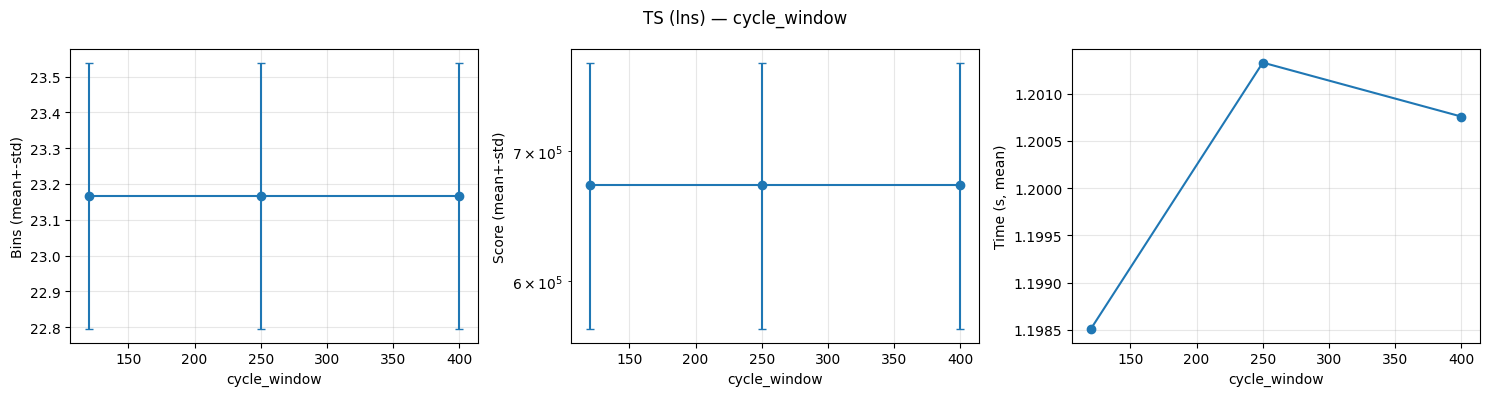

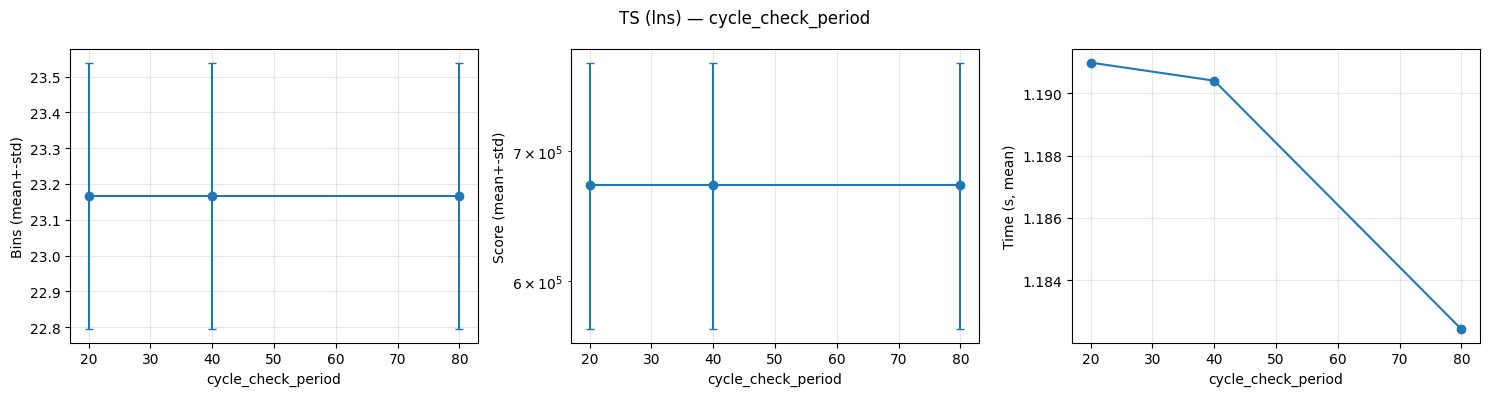

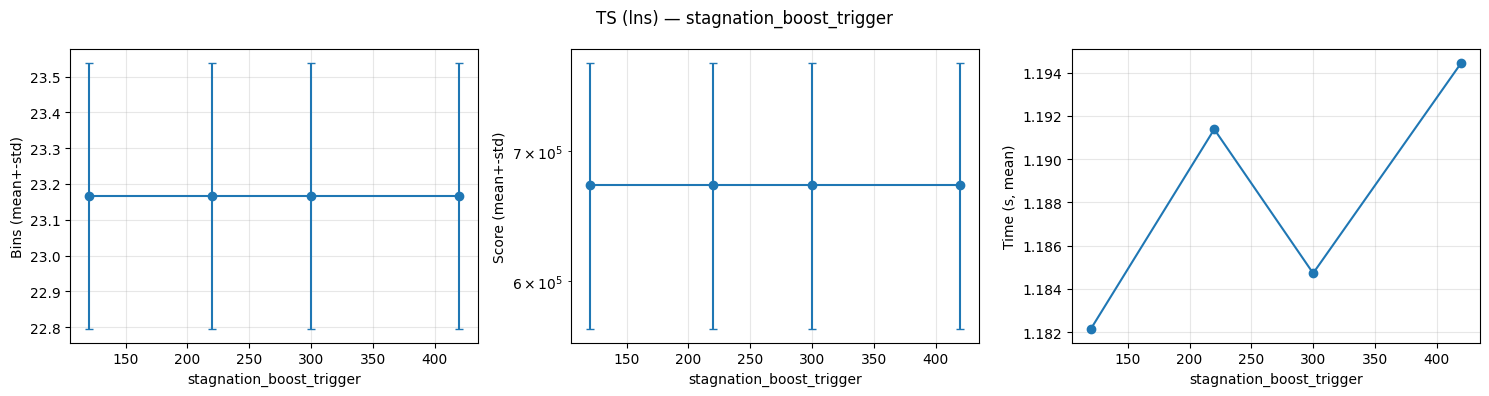

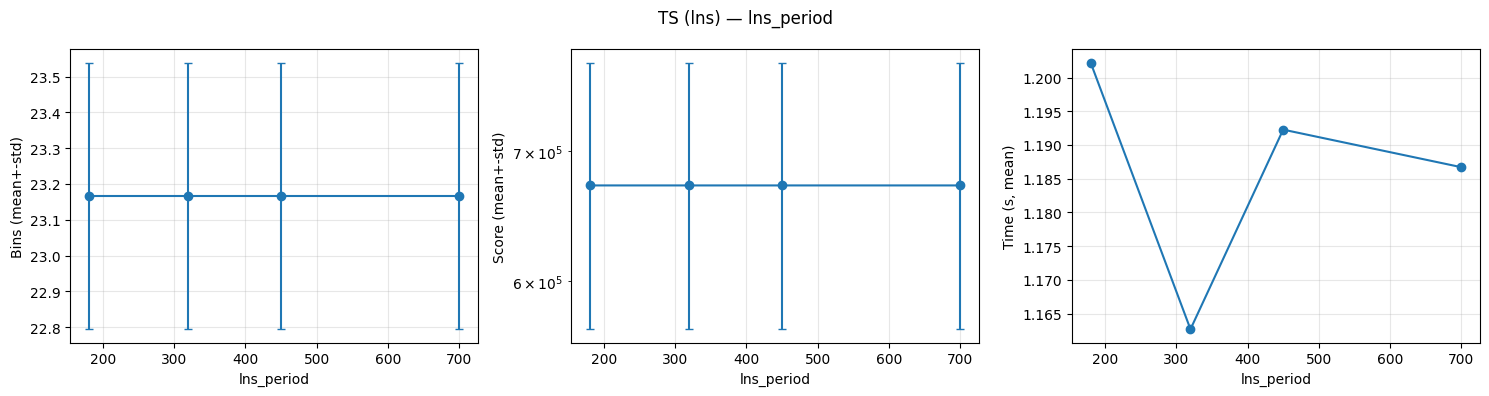

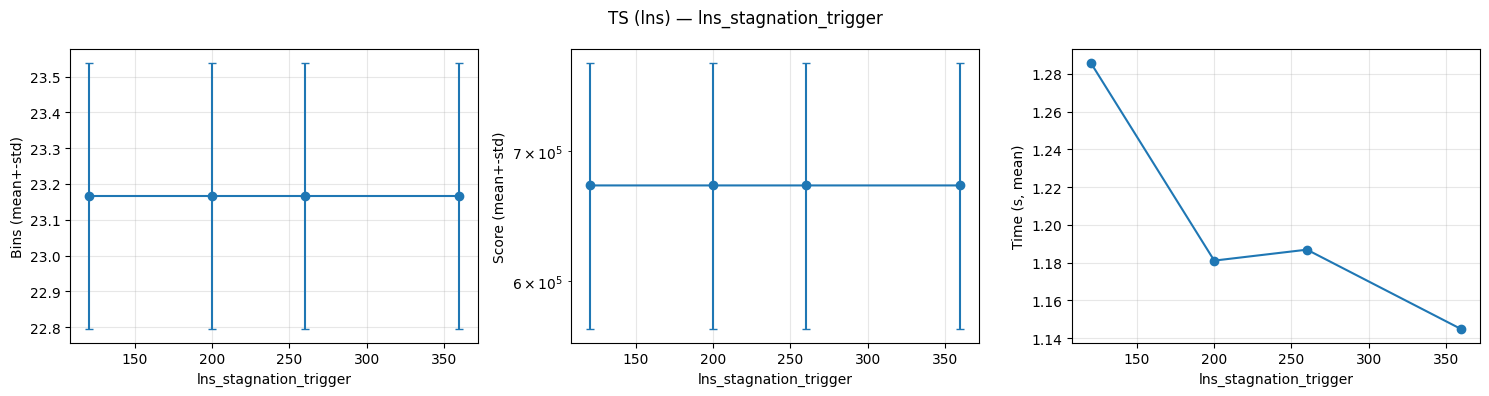

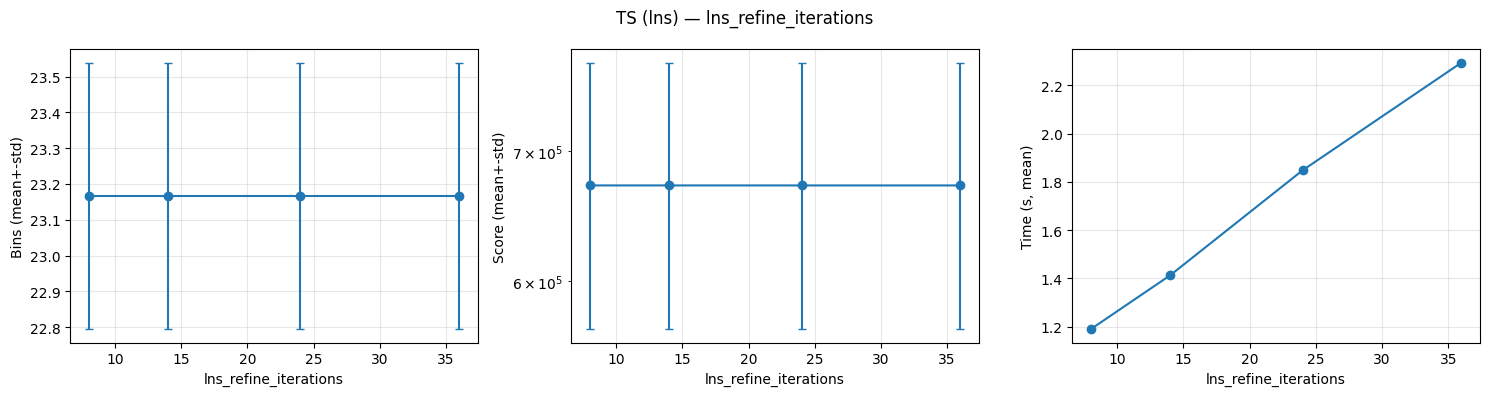

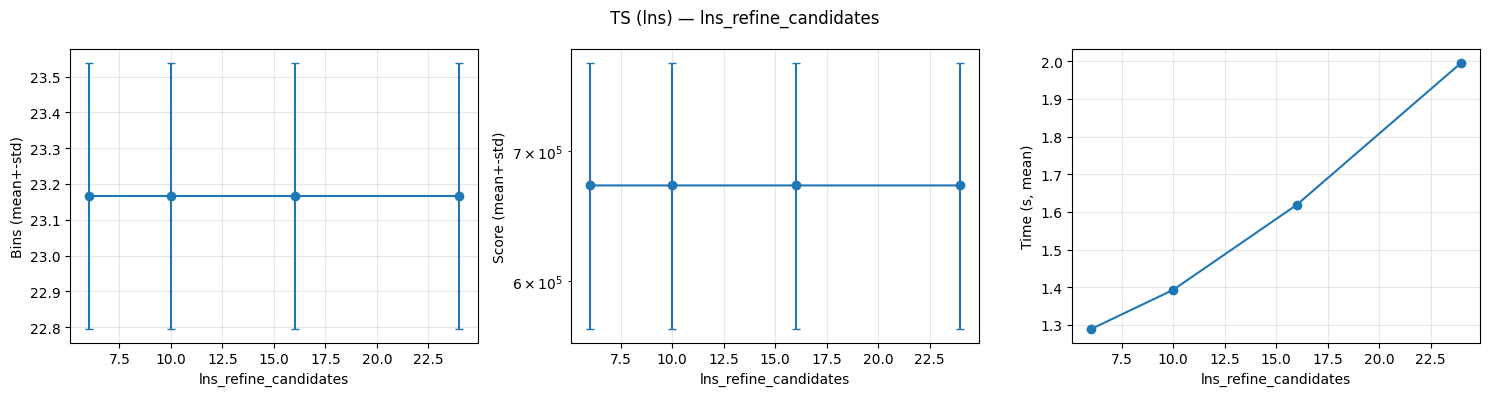


TS sensitivity — hybrid


,variant,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,hybrid,tabu_tenure,2.0,23.166667,0.372678,672333.666667,105407.120496,1.240502
1,hybrid,tabu_tenure,4.0,23.166667,0.372678,672333.666667,105407.120496,1.221036
2,hybrid,tabu_tenure,6.0,23.166667,0.372678,672333.666667,105407.120496,1.202793
3,hybrid,tabu_tenure,10.0,23.166667,0.372678,672333.666667,105407.120496,1.223070
4,hybrid,tabu_tenure,16.0,23.166667,0.372678,672333.666667,105407.120496,1.224732
...,...,...,...,...,...,...,...,...
64,hybrid,diversification_growth,0.1,23.166667,0.372678,672333.666667,105407.120496,1.169739
65,hybrid,diversification_max_weight,8.0,23.166667,0.372678,672333.666667,105407.120496,1.166444
66,hybrid,diversification_max_weight,14.0,23.166667,0.372678,672333.666667,105407.120496,1.189583
67,hybrid,diversification_max_weight,20.0,23.166667,0.372678,672333.666667,105407.120496,1.197476


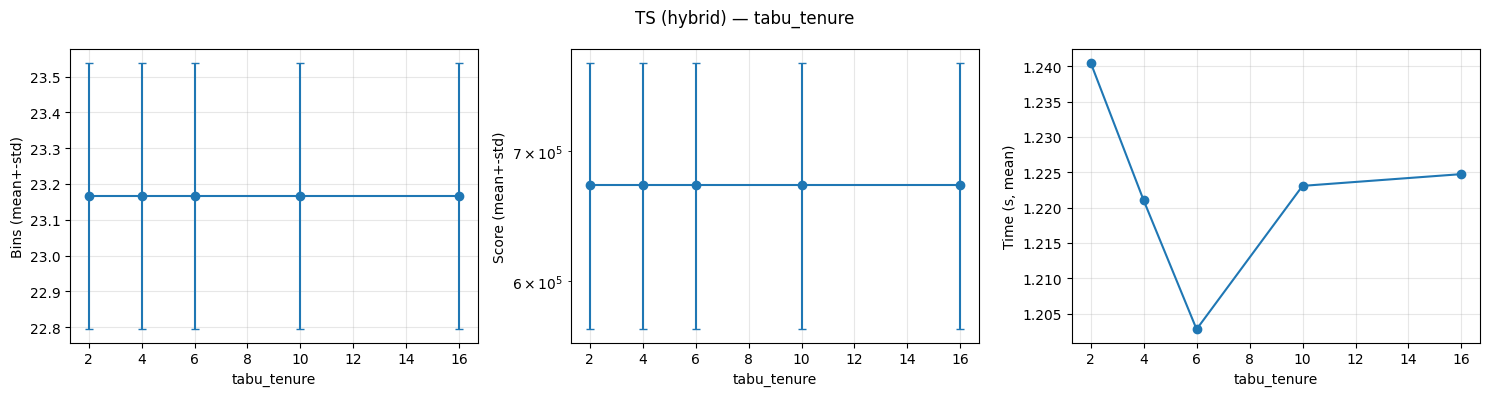

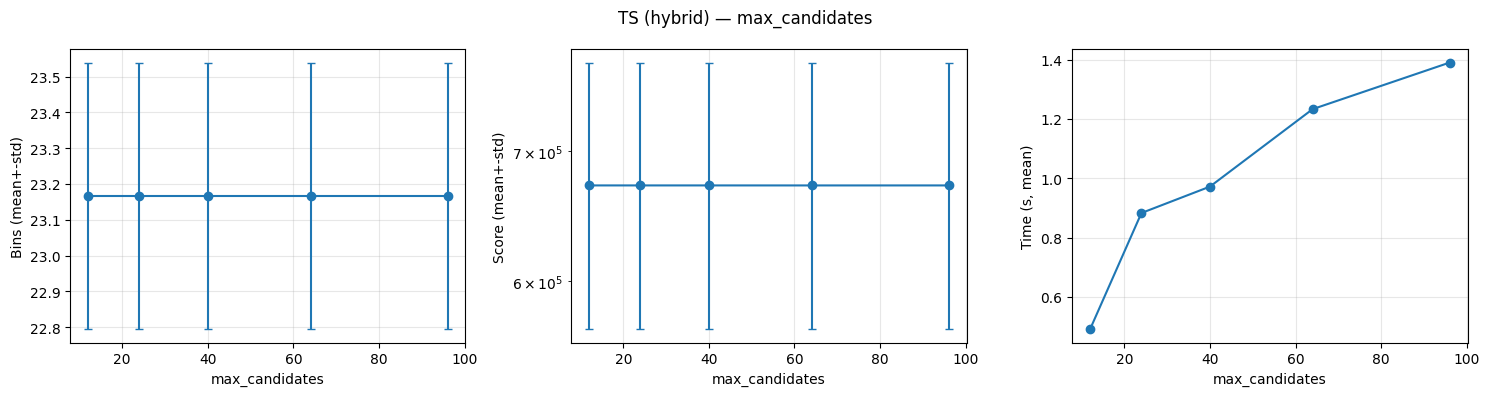

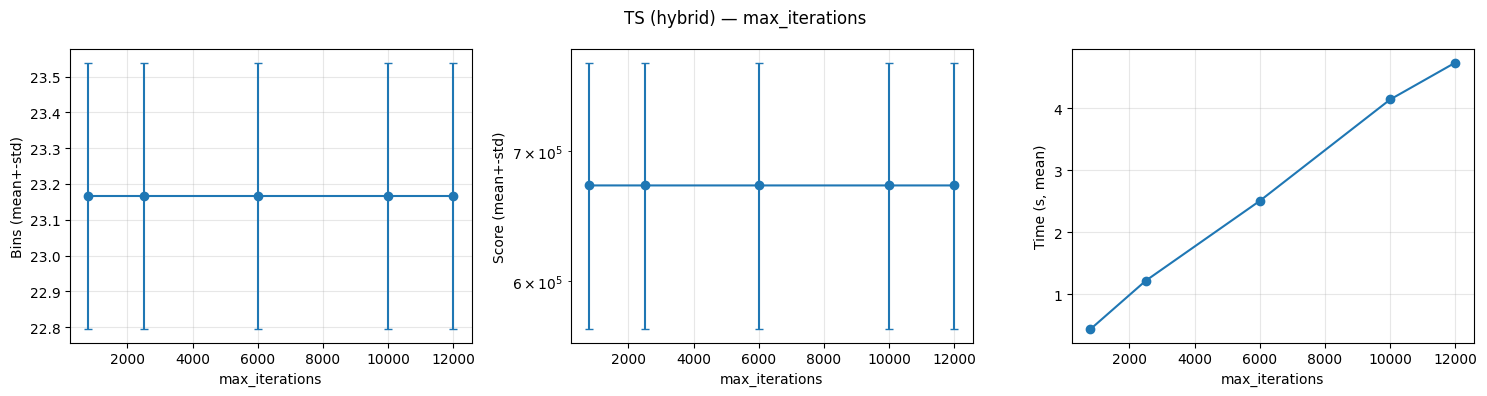

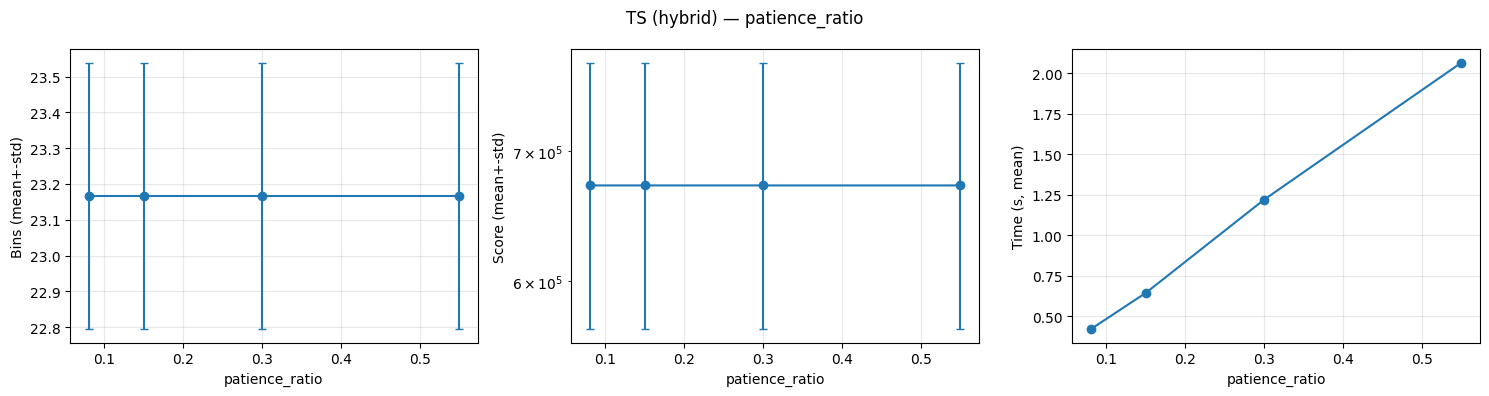

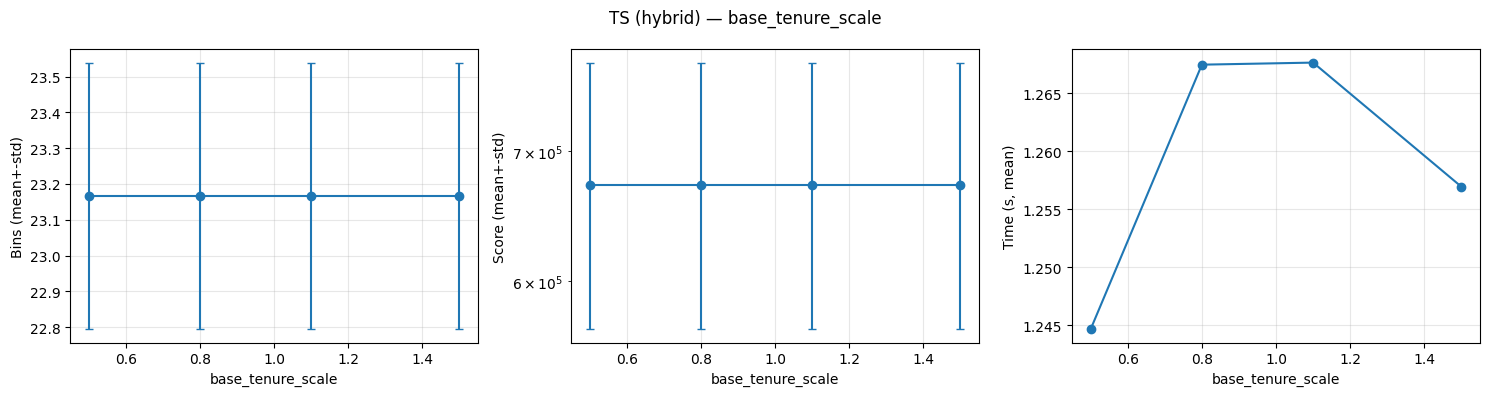

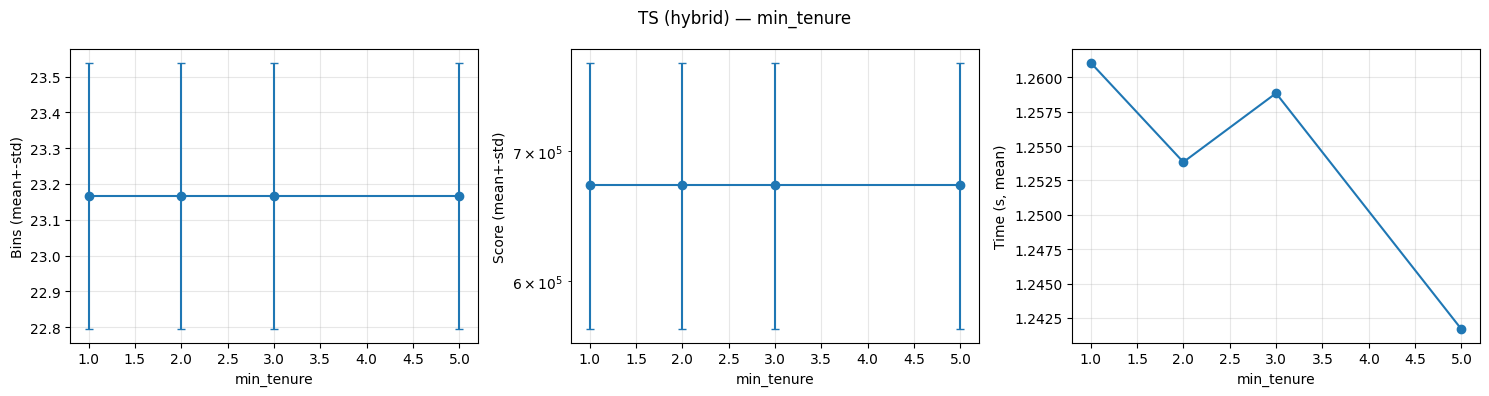

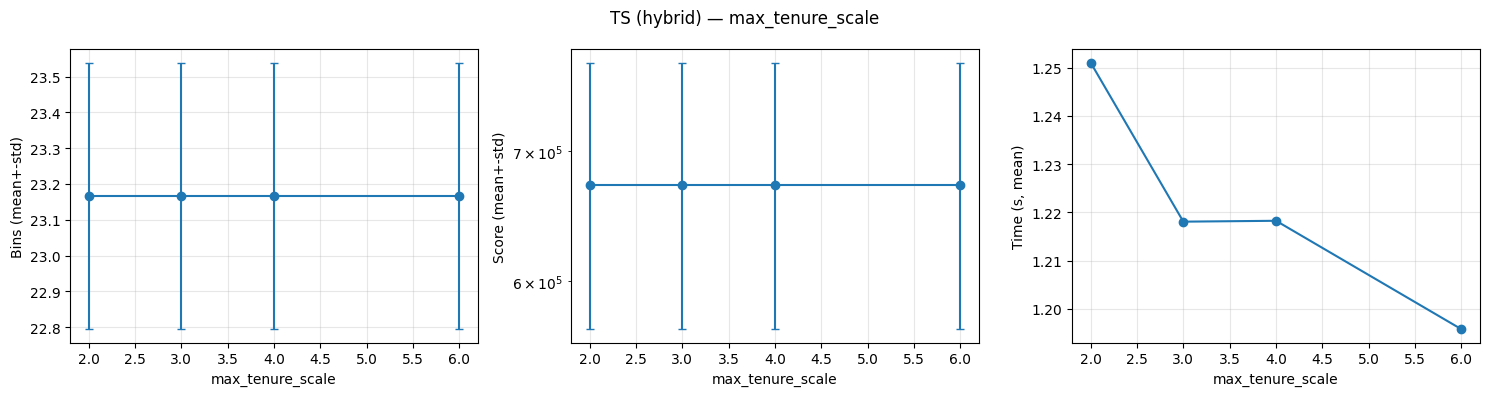

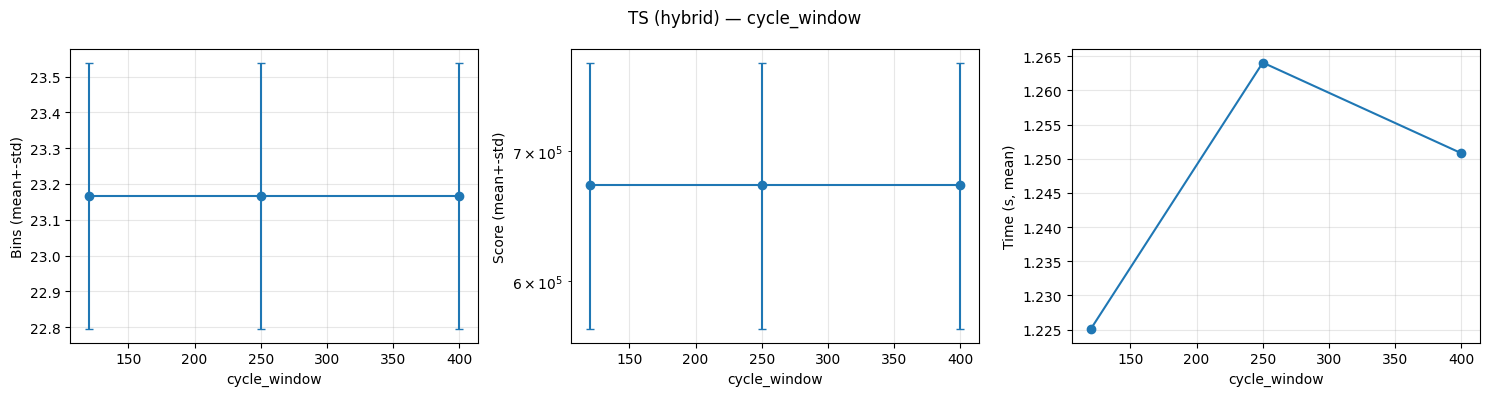

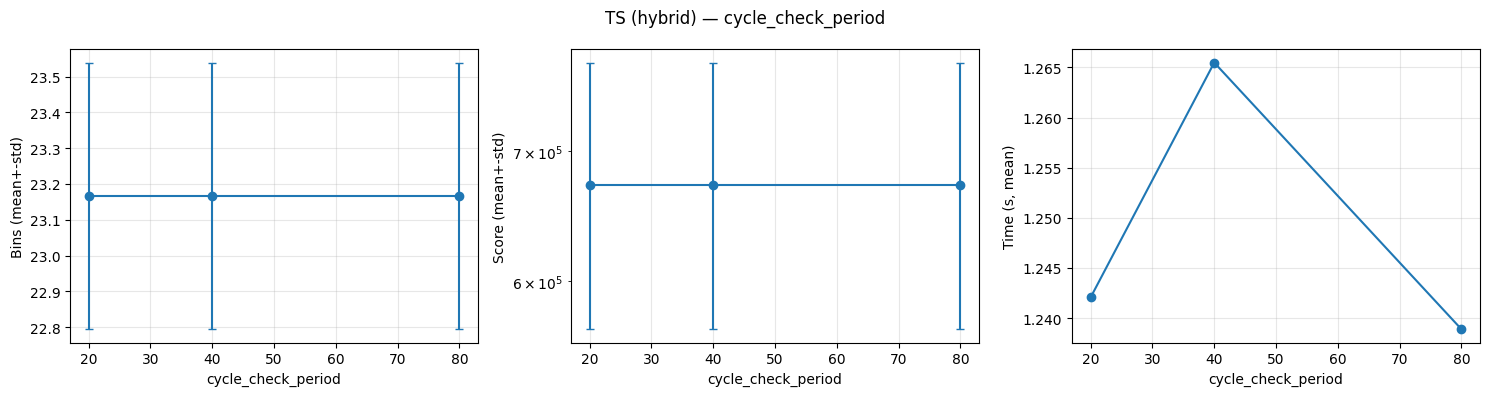

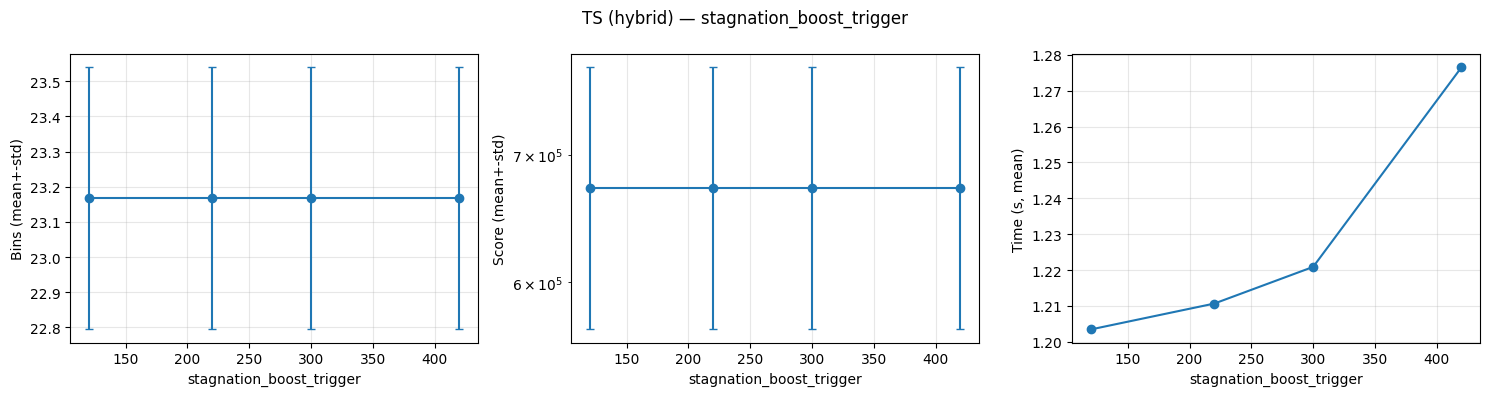

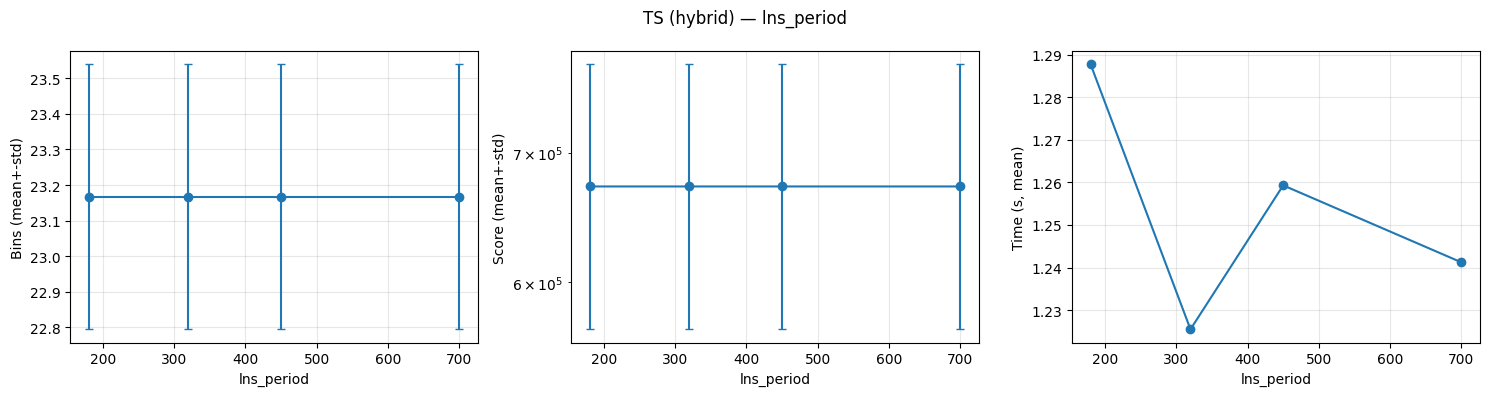

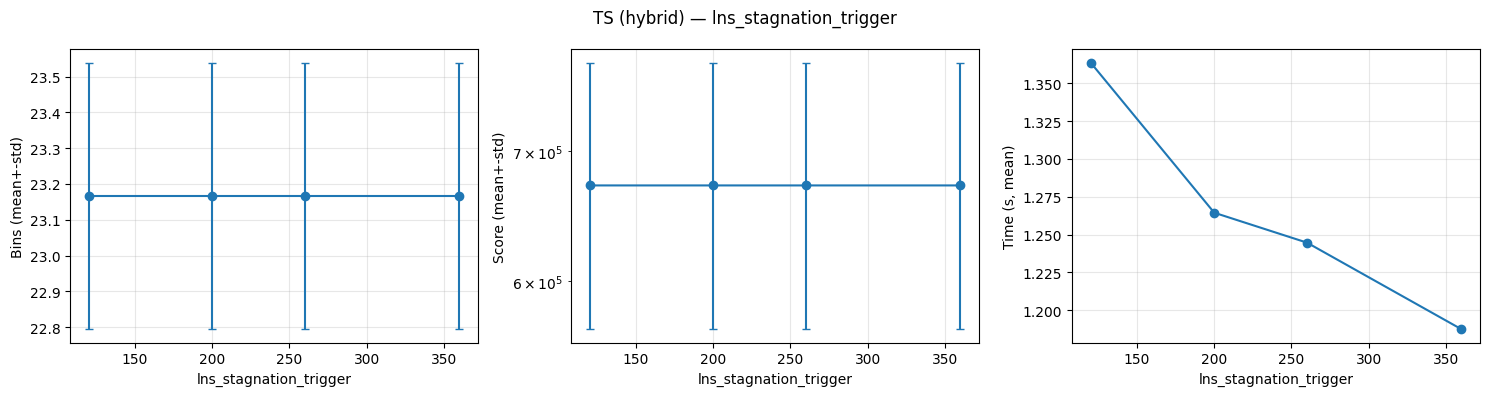

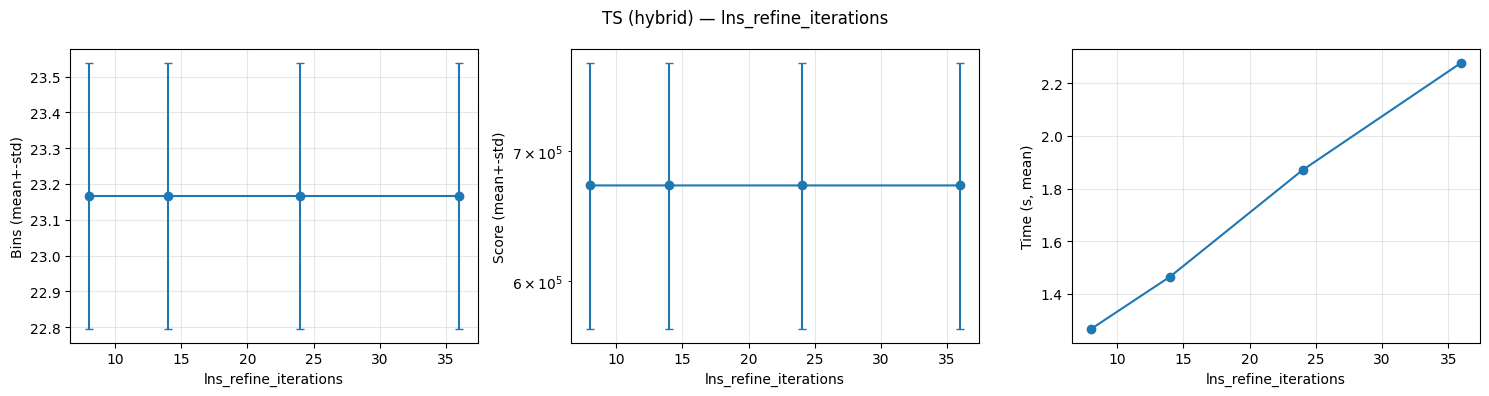

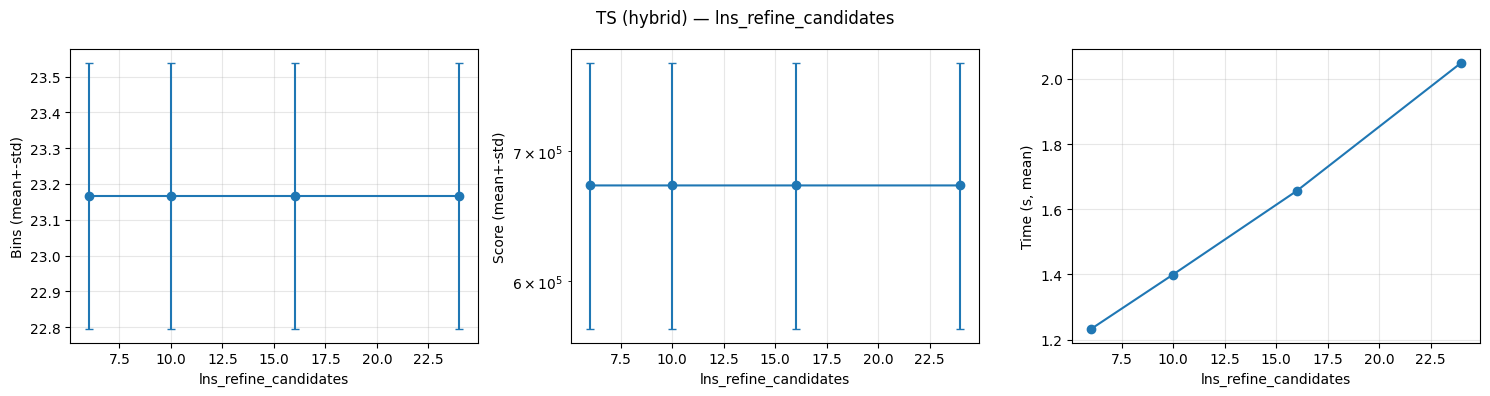

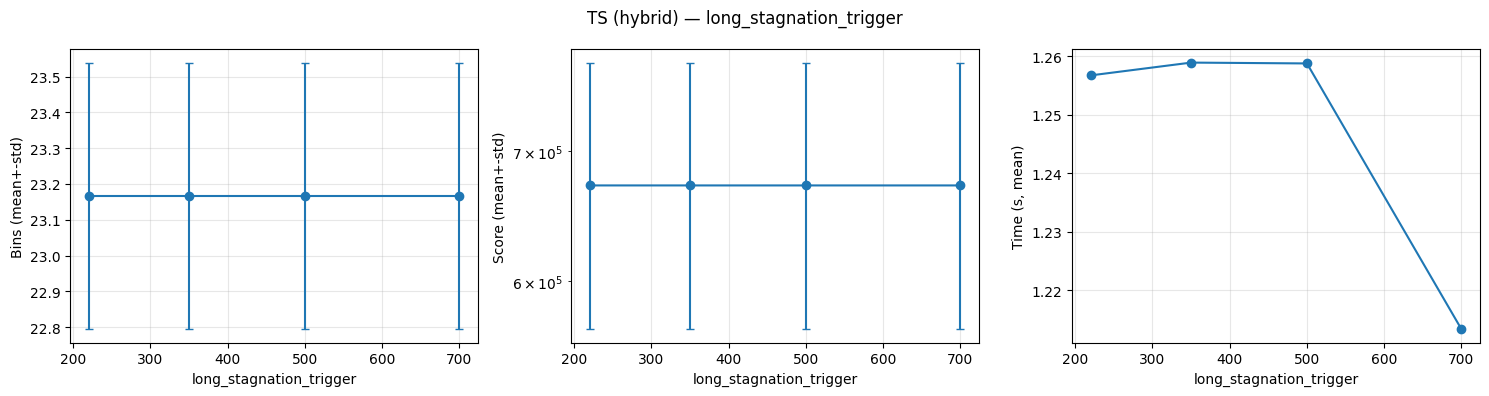

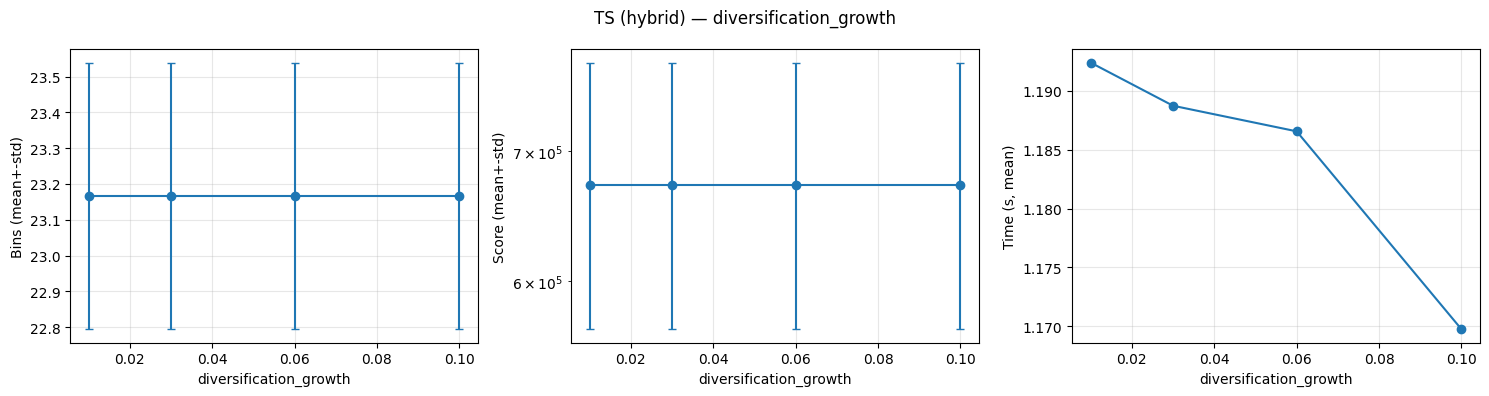

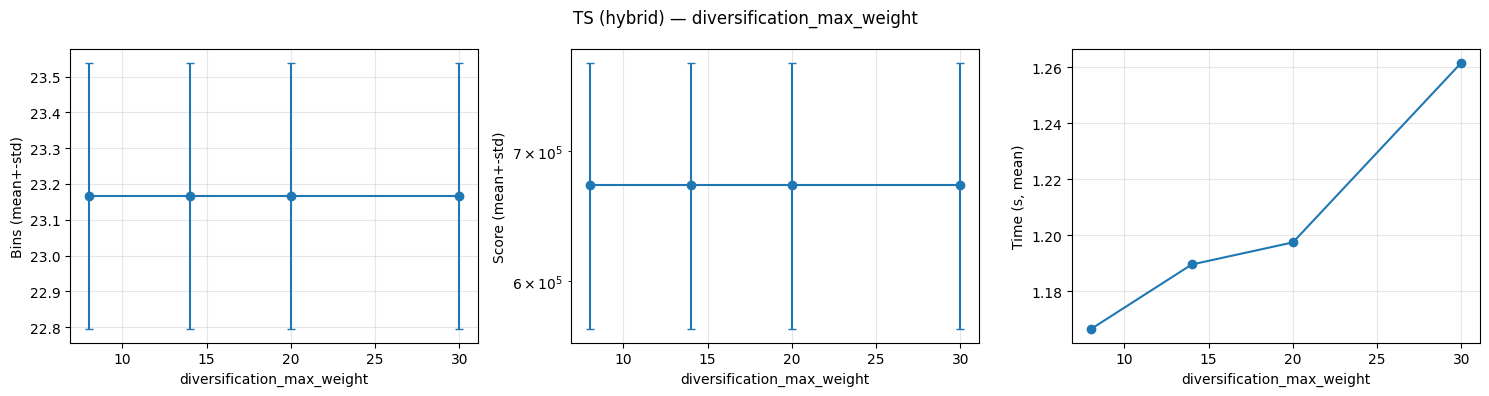

In [ ]:
# ── Sensibilité (variation 1 paramètre, autres fixés) ───────────────────────
TS_VARIANTS_TO_PLOT = ["baseline", "reactive", "lns", "hybrid"]


def ts_sensitivity_for(variant_name: str) -> pd.DataFrame:
    grid = TS_VARIANTS[variant_name]["grid"]
    base_params = best_ts_params_by_variant[variant_name]

    rows: list[dict] = []
    for param, values in grid.items():
        for v in values:
            params = dict(base_params)
            params[param] = v
            summary = eval_ts_variant_params(variant_name, params)
            rows.append(
                {"variant": variant_name, "param": param, "value": v, **summary}
            )

    return pd.DataFrame(rows)


for variant_name in TS_VARIANTS_TO_PLOT:
    print("\n" + "=" * 60)
    print("TS sensitivity —", variant_name)
    df = ts_sensitivity_for(variant_name)
    display(df)
    plot_sensitivity(df, title_prefix=f"TS ({variant_name}) — ")